# Experiment Hub: Approximate Program Synthesis for Efficient ML

Central notebook for running all experiments, collecting data, and plotting results.

**Sections:**
1. Synthesis + Accuracy Pipeline
2. Hyperparameter Sweep
3. Grammar Selection Study
4. Ablation Study (CVC5 vs FloPoCo, Constraint Relaxation, Bitvector Sweep)
5. Cross-cutting Summary

In [18]:
import json
import os

# Ensure iverilog/vvp are on PATH (conda pkg cache on supervisor server)
os.environ["PATH"] = "/home/josephluke/.local/bin:/home/josephluke/.conda/pkgs/iverilog-11.0-hd56c0c9_0/bin:" + os.environ.get("PATH", "")
import re
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    root = Path.cwd().resolve()
    while root != root.parent:
        if (root / "src" / "synthesis_driver.py").exists() and (root / "accuracy_tests" / "Makefile").exists():
            return root
        root = root.parent
    raise RuntimeError("Could not locate repo root")


ROOT = find_repo_root()
ACC_DIR = ROOT / "accuracy_tests"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.run_vitis_hls import parse_reports


# ────────────── Shared helpers ──────────────

def tail(text: str, lines: int = 200) -> str:
    parts = (text or "").splitlines()
    return "\n".join(parts[-lines:])


def extract_metrics(text: str) -> dict:
    """Parse cocotb test output for accuracy metrics (MXINT8 and FP32 formats)."""
    metrics: dict = {}
    for raw in (text or "").splitlines():
        line = raw.strip()
        # MXINT8 format: "Ran N test cases (skipped M)"
        m_ran = re.search(r"Ran\s+\d+\s+(?:test\s+)?cases?\s+\(skipped\s+\d+\)", line)
        if m_ran:
            metrics["ran"] = m_ran.group(0)
        if "Percent Within" in line:
            metrics.setdefault("percent_within", []).append(line)
        if "Exact match (quantized oracle):" in line:
            metrics["mxint8_exact_match"] = line
        if "Max Absolute Error:" in line:
            metrics.setdefault("max_abs", []).append(line)
        if "Average Absolute Error:" in line:
            metrics.setdefault("avg_abs", []).append(line)
        if "99th Percentile" in line:
            metrics.setdefault("p99", []).append(line)
        if "95th Percentile" in line:
            metrics.setdefault("p95", []).append(line)
        # FP32 inline format: "[IN-DIST ...] ... Exact match: X%. Within Y% relative error: Z%"
        # or untagged: "Ran N cases (skipped M). Exact match: X%. Within Y% relative error: Z%"
        if "[IN-DIST" in line or "[GENERALISATION" in line:
            metrics.setdefault("fp32_inline", []).append(line)
            m_ran2 = re.search(r"Ran\s+\d+\s+cases\s+\(skipped\s+\d+\)", line)
            if m_ran2:
                metrics["ran"] = m_ran2.group(0)
        elif "Exact match:" in line and "Within" in line and "relative error" in line:
            metrics.setdefault("fp32_inline", []).append("[IN-DIST] " + line)
            m_ran2 = re.search(r"Ran\s+\d+\s+cases\s+\(skipped\s+\d+\)", line)
            if m_ran2:
                metrics["ran"] = m_ran2.group(0)
    return metrics


def extract_mxint8_variant_metrics(text: str, variant: str) -> dict:
    """Extract the MXINT8 metrics block matching the requested grammar variant."""
    label = {
        "Subcomponents": "subcomponents",
        "V1": "v1",
        "V2": "v2",
    }.get(variant, str(variant).lower())
    starts = list(re.finditer(r"Starting MXINT8 (?:adder|multiplier) accuracy test \((subcomponents|v1|v2)\)", text or ""))
    if not starts:
        return extract_metrics(text)
    for idx, match in enumerate(starts):
        if match.group(1) != label:
            continue
        end = starts[idx + 1].start() if idx + 1 < len(starts) else len(text or "")
        return extract_metrics((text or "")[match.start():end])
    return extract_metrics(text)


def parse_accuracy_rc_from_driver(text: str):
    if "[SUCCESS] Accuracy run completed successfully." in text:
        return 0
    if "[ACC] Accuracy run completed successfully (rc=0)." in text:
        return 0
    m = re.search(r"Accuracy run failed with return code\s+(\d+)", text)
    return int(m.group(1)) if m else None


def _parse_ran(line):
    m = re.search(r"Ran\s+(\d+)\s+(?:test\s+)?cases?\s+\(skipped\s+(\d+)\)", line or "")
    return (int(m.group(1)), int(m.group(2))) if m else (np.nan, np.nan)


def _parse_value_after_colon(line):
    m = re.search(r":\s*(-?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)", line or "")
    return float(m.group(1)) if m else np.nan


def _parse_percent_after_colon(line):
    m = re.search(r":\s*([0-9]+(?:\.[0-9]+)?)\s*%", line or "")
    return float(m.group(1)) if m else np.nan


def tol_tag(value: float) -> str:
    return str(value).replace(".", "p")


def parse_mode_tol(tag: str) -> tuple:
    m = re.match(r"^mode_(.+)__rel_([0-9p]+)$", tag)
    if not m:
        return ("unknown", float("nan"))
    return (m.group(1), float(m.group(2).replace("p", ".")))


print(f"Repo root: {ROOT}")
print("Setup complete.")

Repo root: /home/josephluke/Program-Synthesis-for-Efficient-ML
Setup complete.


# 1. Synthesis + Accuracy Pipeline

Runs SMT synthesis, hardware synthesis (Vitis HLS + Vivado), and cocotb accuracy tests for all targets.
Covers `FP32` and `MXINT8` addition/multiplication — both `subcomponent` and `combined` variants, plus FloPoCo baselines.

In [19]:
# ──────── Load Pipeline Results from HLS Output Directories ────────
# Scans results/HLS/solution_* for Vivado reports (post-impl) and
# results/{c,cpp}/ for solution files. Accuracy is parsed from pipeline logs.

PIPELINE_TARGETS = [
    {"name": "mxint8_add_subcomponents", "op": "Addition",       "dtype": "MXINT8", "variant": "Subcomponents", "soln": "solution_mxint8addition_full_sum",               "top": "add_full_sum",            "base": "HLS"},
    {"name": "mxint8_add_v1",            "op": "Addition",       "dtype": "MXINT8", "variant": "V1",            "soln": "solution_mxint8addition_full_sum_v1",             "top": "add_full_sum",            "base": "HLS"},
    {"name": "mxint8_add_v2",            "op": "Addition",       "dtype": "MXINT8", "variant": "V2",            "soln": "solution_mxint8addition_full_sum_v2",             "top": "add_full_sum",            "base": "HLS"},
    {"name": "mxint8_mul_subcomponents", "op": "Multiplication", "dtype": "MXINT8", "variant": "Subcomponents", "soln": "solution_mxint8multiplication_full_product",      "top": "mult_mxint_full_product", "base": "HLS"},
    {"name": "mxint8_mul_v1",            "op": "Multiplication", "dtype": "MXINT8", "variant": "V1",            "soln": "solution_mxint8multiplication_full_product_v1",   "top": "mult_mxint_full_product", "base": "HLS"},
    {"name": "mxint8_mul_v2",            "op": "Multiplication", "dtype": "MXINT8", "variant": "V2",            "soln": "solution_mxint8multiplication_full_product_v2",   "top": "mult_mxint_full_product", "base": "HLS"},
    {"name": "fp32_add_subcomponents",   "op": "Addition",       "dtype": "FP32",   "variant": "Subcomponents", "soln": "solution_fp32addition_full_sum",                  "top": "fp32_sum",                "base": "HLS"},
    {"name": "fp32_add_v1",              "op": "Addition",       "dtype": "FP32",   "variant": "V1",            "soln": "solution_fp32addition_full_sum_v1",               "top": "fp32_sum",                "base": "HLS"},
    {"name": "fp32_add_v2",              "op": "Addition",       "dtype": "FP32",   "variant": "V2",            "soln": "solution_fp32addition_full_sum_v2",               "top": "fp32_sum",                "base": "HLS"},
    {"name": "fp32_mul_subcomponents",   "op": "Multiplication", "dtype": "FP32",   "variant": "Subcomponents", "soln": "solution_fp32multiplication_full_product",        "top": "fp32_full_mul",           "base": "HLS"},
    {"name": "fp32_mul_v1",              "op": "Multiplication", "dtype": "FP32",   "variant": "V1",            "soln": "solution_fp32multiplication_full_product_v1",     "top": "fp32_full_mul",           "base": "HLS"},
    {"name": "fp32_mul_v2",              "op": "Multiplication", "dtype": "FP32",   "variant": "V2",            "soln": "solution_fp32multiplication_full_product_v2",     "top": "fp32_full_mul",           "base": "HLS"},
    {"name": "fp32_add_flopoco",         "op": "Addition",       "dtype": "FP32",   "variant": "FloPoCo",       "soln": "solution_fp32addition_flopoco",                   "top": "fp32_sum_flopoco",        "base": "FLOPOCO"},
    {"name": "fp32_mul_flopoco",         "op": "Multiplication", "dtype": "FP32",   "variant": "FloPoCo",       "soln": "solution_fp32multiplication_flopoco",             "top": "fp32_full_mul_flopoco",   "base": "FLOPOCO"},
]

# ── Build hardware DataFrame by parsing Vivado reports ──
hw_rows = []
for t in PIPELINE_TARGETS:
    out_dir = ROOT / "results" / t["base"] / t["soln"]
    row = {**t, "exists": out_dir.exists()}
    if out_dir.exists():
        hw = parse_reports(out_dir, t["top"], t["soln"], run_impl=True)
        row.update(hw)
    else:
        for c in ["LUTs", "FFs", "DSPs", "BRAMs", "Cycles", "Fmax_MHz", "Latency_ns"]:
            row[c] = np.nan
    hw_rows.append(row)

hw_df = pd.DataFrame(hw_rows)

# ── Parse accuracy from pipeline logs (one per component) ──
if "extract_mxint8_variant_metrics" not in globals():
    def extract_mxint8_variant_metrics(text: str, variant: str) -> dict:
        label = {
            "Subcomponents": "subcomponents",
            "V1": "v1",
            "V2": "v2",
        }.get(variant, str(variant).lower())
        starts = list(re.finditer(r"Starting MXINT8 (?:adder|multiplier) accuracy test \((subcomponents|v1|v2)\)", text or ""))
        if not starts:
            return extract_metrics(text)
        for idx, match in enumerate(starts):
            if match.group(1) != label:
                continue
            end = starts[idx + 1].start() if idx + 1 < len(starts) else len(text or "")
            return extract_metrics((text or "")[match.start():end])
        return extract_metrics(text)

acc_rows = []
for t in PIPELINE_TARGETS:
    log_candidates = sorted(
        (ROOT / "logs").glob(f"pipeline_{t['name'].split('_')[0]}_{t['name'].split('_')[1]}*.log"),
        key=lambda p: p.stat().st_mtime, reverse=True
    )
    metrics = {}
    acc_rc = None
    for lf in log_candidates:
        text = lf.read_text(errors="ignore").replace("\x00", "")
        # Only trust solution-specific sections, and prefer the latest one
        sec_matches = list(re.finditer(rf'HLS_SOLN={re.escape(t["soln"])}(?=\s).*?(?=HLS_SOLN=|\Z)', text, re.DOTALL))
        if sec_matches:
            chosen = None
            for sm in reversed(sec_matches):
                sec = sm.group(0)
                cand_metrics = extract_mxint8_variant_metrics(sec, t["variant"]) if t["dtype"] == "MXINT8" else extract_metrics(sec)
                cand_rc = parse_accuracy_rc_from_driver(sec)
                if t["dtype"] == "MXINT8":
                    has_metrics = bool(cand_metrics.get("mxint8_exact_match")) or bool(cand_metrics.get("percent_within"))
                else:
                    has_metrics = bool(cand_metrics.get("fp32_inline"))
                if has_metrics or cand_rc is not None:
                    chosen = (cand_metrics, cand_rc)
                    break
            if chosen is None:
                sec = sec_matches[-1].group(0)
                chosen = (
                    extract_mxint8_variant_metrics(sec, t["variant"]) if t["dtype"] == "MXINT8" else extract_metrics(sec),
                    parse_accuracy_rc_from_driver(sec),
                )
            metrics, acc_rc = chosen
            break

    m = metrics
    tested, skipped = _parse_ran(m.get("ran"))
    mxint8_exact_line = m.get("mxint8_exact_match", "")
    mxint8_exact = _parse_percent_after_colon(mxint8_exact_line) if mxint8_exact_line else np.nan
    row = {
        "name": t["name"], "op": t["op"], "dtype": t["dtype"], "variant": t["variant"],
        "status": "SKIP" if acc_rc is None else ("PASS" if acc_rc == 0 else "FAIL"),
        "tested": tested, "skipped": skipped,
        "mxint8_exact_pct": mxint8_exact,
    }
    # MXINT8 metrics
    for prefix, idx in [("quant", 0), ("full", 1)]:
        for key, parser in [("max_abs", _parse_value_after_colon),
                            ("avg_abs", _parse_value_after_colon),
                            ("p99", _parse_value_after_colon)]:
            vals = m.get(key, [])
            row[f"{prefix}_{key}"] = parser(vals[idx]) if len(vals) > idx else np.nan
        pctw = m.get("percent_within", [])
        row[f"{prefix}_pct_within_fs"] = _parse_percent_after_colon(pctw[idx]) if len(pctw) > idx else np.nan

    # FP32 inline metrics
    for fp_line in m.get("fp32_inline", []):
        m_exact = re.search(r"Exact match:\s*([\d.]+)%", fp_line)
        m_within = re.search(r"Within\s+\d+%\s+relative error:\s*([\d.]+)%", fp_line)
        if "[IN-DIST" in fp_line:
            if m_exact: row["fp32_indist_exact"] = float(m_exact.group(1))
            if m_within: row["fp32_indist_within_rel"] = float(m_within.group(1))
        elif "[GENERALISATION" in fp_line:
            if m_exact: row["fp32_gen_exact"] = float(m_exact.group(1))
            if m_within: row["fp32_gen_within_rel"] = float(m_within.group(1))
    acc_rows.append(row)

acc_df = pd.DataFrame(acc_rows)

# ── Merge hardware + accuracy ──
merged = hw_df.merge(acc_df.drop(columns=["name"], errors="ignore"),
                     on=["op", "dtype", "variant"], how="left")
for col in ["Fmax_MHz", "LUTs", "FFs", "DSPs", "BRAMs", "Cycles", "Latency_ns"]:
    if col in merged.columns:
        merged[col] = merged[col].replace(-1, np.nan)

# Unified accuracy column: MXINT8 uses quant_pct_within_fs, FP32 uses fp32_indist_within_rel
_fp32_within = merged.get("fp32_indist_within_rel", np.nan)
merged["within5pct"] = np.where(merged["dtype"] == "MXINT8", merged["quant_pct_within_fs"], _fp32_within)

# Exact match column: FP32 uses fp32_indist_exact, MXINT8 uses mxint8_exact_pct
_fp32_exact = merged.get("fp32_indist_exact", np.nan)
_mxint8_exact = merged.get("mxint8_exact_pct", np.nan)
merged["exact_pct"] = np.where(merged["dtype"] == "FP32", _fp32_exact, _mxint8_exact)

# ADP = LUTs * Latency_ns (keep consistent with sweep outputs; DSPs not weighted here)
merged["LUT_equiv"] = merged["LUTs"].fillna(0) + merged["DSPs"].fillna(0) * 150
merged["ADP"] = merged["LUTs"] * merged["Latency_ns"]

# ── Override FloPoCo rows with data from the latest FloPoCo BV sweep CSVs (m=24) ──
def _latest_flopoco_summary(target_key: str, preferred_mode: str = "normal_full"):
    base_names = [f"flopoco_bitvector_impl_{target_key}", f"flopoco_bitvector_{target_key}"]
    candidates = []
    for base_name in base_names:
        base_dir = ROOT / "results" / "sweeps" / base_name
        if not base_dir.exists():
            continue
        mode_csvs = list(base_dir.glob("*/summary.csv"))
        direct_csv = base_dir / "summary.csv"
        if direct_csv.exists():
            mode_csvs.append(direct_csv)
        candidates.extend(mode_csvs)
    if not candidates:
        return None
    preferred = [p for p in candidates if p.parent.name == preferred_mode]
    pool = preferred if preferred else candidates
    return max(pool, key=lambda p: p.stat().st_mtime)

flopoco_csv_map = {
    "fp32_add_flopoco": _latest_flopoco_summary("fp32_add"),
    "fp32_mul_flopoco": _latest_flopoco_summary("fp32_mul"),
}
for tname, csv_path in flopoco_csv_map.items():
    if csv_path is not None:
        print(f"[FloPoCo] Using {csv_path}")
    if csv_path is not None and csv_path.exists():
        fpc = pd.read_csv(csv_path)
        row24 = fpc[fpc["mantissa_bits"] == 24]
        if not row24.empty:
            r = row24.iloc[0]
            mask = merged["name"] == tname
            for col, val in [("LUTs", r.get("LUTs", np.nan)),
                             ("DSPs", r.get("DSPs", np.nan)),
                             ("FFs",  r.get("FFs",  np.nan)),
                             ("Fmax_MHz",  r.get("Fmax_MHz",  np.nan)),
                             ("Latency_ns", r.get("Latency_ns", np.nan)),
                             ("within5pct", r.get("within_rel_pct", np.nan) * 100
                              if not pd.isna(r.get("within_rel_pct", np.nan)) else np.nan)]:
                merged.loc[mask, col] = val
            # Recompute area proxy and LUT-only ADP for FloPoCo rows
            merged.loc[mask, "LUT_equiv"] = merged.loc[mask, "LUTs"].fillna(0) + merged.loc[mask, "DSPs"].fillna(0) * 150
            merged.loc[mask, "ADP"] = merged.loc[mask, "LUTs"] * merged.loc[mask, "Latency_ns"]
            merged.loc[mask, "exists"] = True
            merged.loc[mask, "exact_pct"] = 100.0

# ── Display summary tables (split by dtype) ──
display_cols = [c for c in ["op", "variant", "status", "LUTs", "FFs", "DSPs",
                             "Fmax_MHz", "Latency_ns", "ADP", "within5pct", "exact_pct"] if c in merged.columns]
n_found = merged["exists"].sum()
print(f"Pipeline results: {n_found}/{len(PIPELINE_TARGETS)} HLS directories found")

for dtype_label in ["FP32", "MXINT8"]:
    view = (merged[merged["dtype"] == dtype_label][display_cols]
            .sort_values(["op", "variant"]).reset_index(drop=True))
    print(f"── {dtype_label} Results ──")
    display(view)

[FloPoCo] Using /home/josephluke/Program-Synthesis-for-Efficient-ML/results/sweeps/flopoco_bitvector_impl_fp32_add/normal_full/summary.csv
[FloPoCo] Using /home/josephluke/Program-Synthesis-for-Efficient-ML/results/sweeps/flopoco_bitvector_impl_fp32_mul/normal_full/summary.csv
Pipeline results: 14/14 HLS directories found
── FP32 Results ──


,op,variant,status,LUTs,FFs,DSPs,Fmax_MHz,Latency_ns,ADP,within5pct,exact_pct
0,Addition,FloPoCo,SKIP,401.0,247.0,0.0,963.391,5.190,2081.190,100.00,100.00
1,Addition,Subcomponents,PASS,458.0,0.0,0.0,239.177,4.181,1914.898,100.00,65.56
2,Addition,V1,PASS,331.0,0.0,0.0,133.316,7.501,2482.831,15.01,11.29
3,Addition,V2,PASS,426.0,0.0,0.0,239.292,4.179,1780.254,44.54,29.11
4,Multiplication,FloPoCo,SKIP,144.0,70.0,2.0,174.064,5.745,827.280,100.00,100.00
5,Multiplication,Subcomponents,PASS,32.0,0.0,2.0,74.355,13.449,430.368,90.46,90.46
6,Multiplication,V1,PASS,32.0,0.0,2.0,87.283,11.457,366.624,90.46,62.73
7,Multiplication,V2,PASS,32.0,0.0,2.0,87.283,11.457,366.624,90.46,90.46


── MXINT8 Results ──


,op,variant,status,LUTs,FFs,DSPs,Fmax_MHz,Latency_ns,ADP,within5pct,exact_pct
0,Addition,Subcomponents,PASS,59.0,0.0,0.0,34.050,29.3686,1732.7474,67.46,52.81
1,Addition,V1,PASS,53.0,0.0,0.0,46.990,21.2811,1127.8983,29.27,18.81
2,Addition,V2,PASS,26.0,0.0,0.0,69.425,14.4040,374.5040,15.24,10.88
3,Multiplication,Subcomponents,PASS,53.0,0.0,0.0,76.283,13.1091,694.7823,78.92,67.83
4,Multiplication,V1,PASS,23.0,0.0,0.0,427.350,2.3400,53.8200,85.82,45.32
5,Multiplication,V2,PASS,23.0,0.0,0.0,427.350,2.3400,53.8200,85.91,45.32


# 2. Hyperparameter Sweep

Sweeps solver `timeout` and `num_iterations` to find the optimal balance for each synthesis target.
Supports 1D sweeps (`timeout-sweep`, `iter-sweep`) and 2D joint grid (`joint`).
Uses `--patience` for early stopping when metrics plateau.

Loaded 720 raw runs from 'fine_v4' (1 file(s))
Source of truth: /home/josephluke/Program-Synthesis-for-Efficient-ML/results/hyperparameter_sweep/fine_v4/runs.jsonl
Metrics present -> within-threshold: True | exact: True | LUTs: True | latency: True | ADP: True
Grid audit: 12 benchmarks x 5 timeouts x 4 iteration counts x 3 reps = 720 expected runs
Completed: 720 / 720 (100.0%)
                                Benchmark  Completed  Expected  Completion %  \
0                      FP32 Addition (V2)         60        60         100.0   
1           FP32 Addition (Subcomponents)         60        60         100.0   
2                      FP32 Addition (V1)         60        60         100.0   
3                FP32 Multiplication (V2)         60        60         100.0   
4     FP32 Multiplication (Subcomponents)         60        60         100.0   
5                FP32 Multiplication (V1)         60        60         100.0   
6                    MXINT8 Addition (V2)         60        

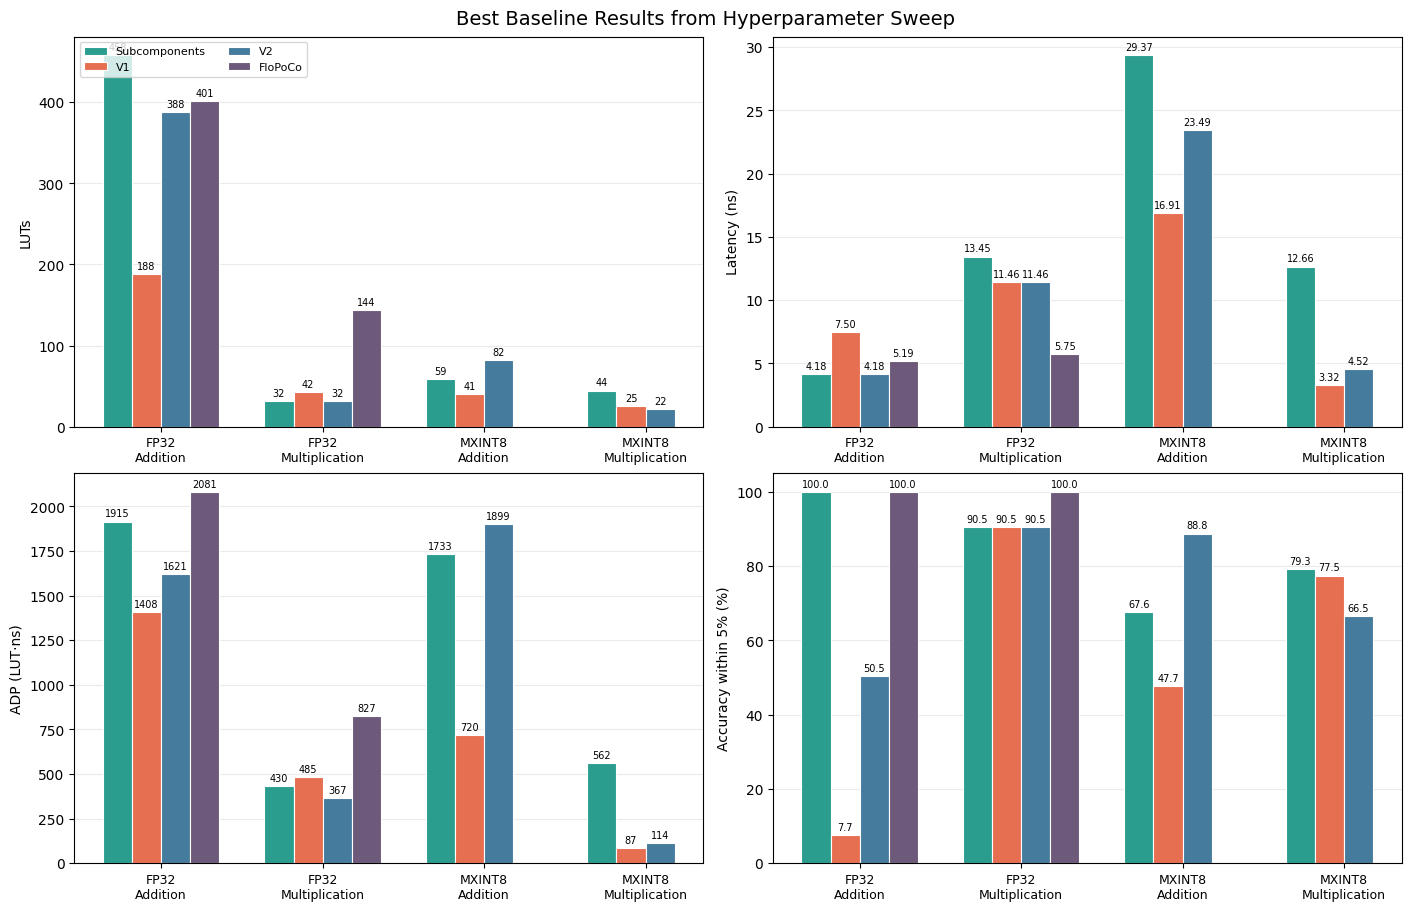

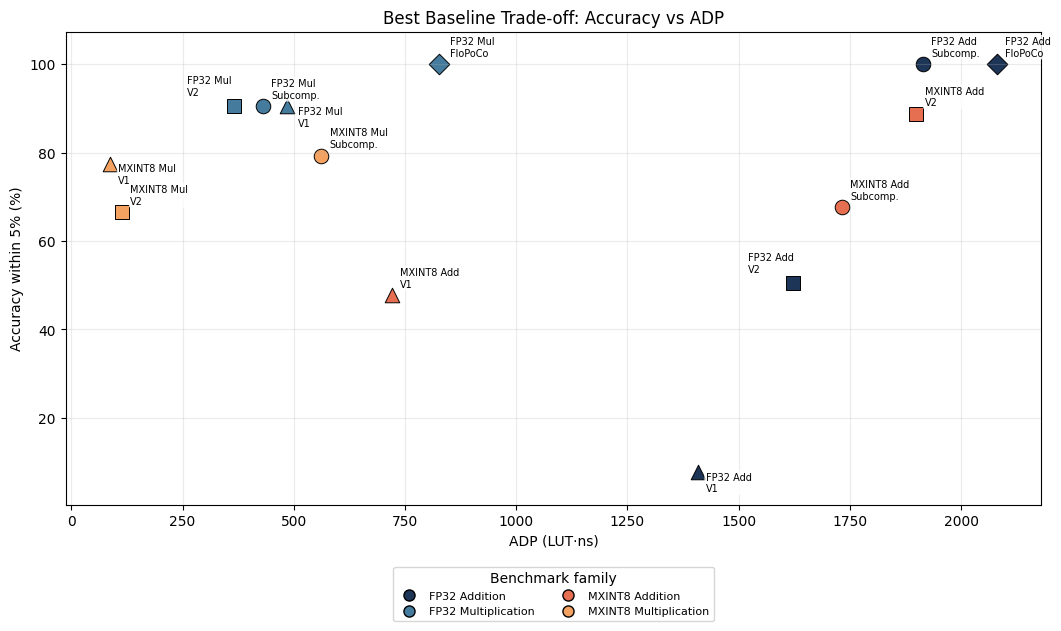

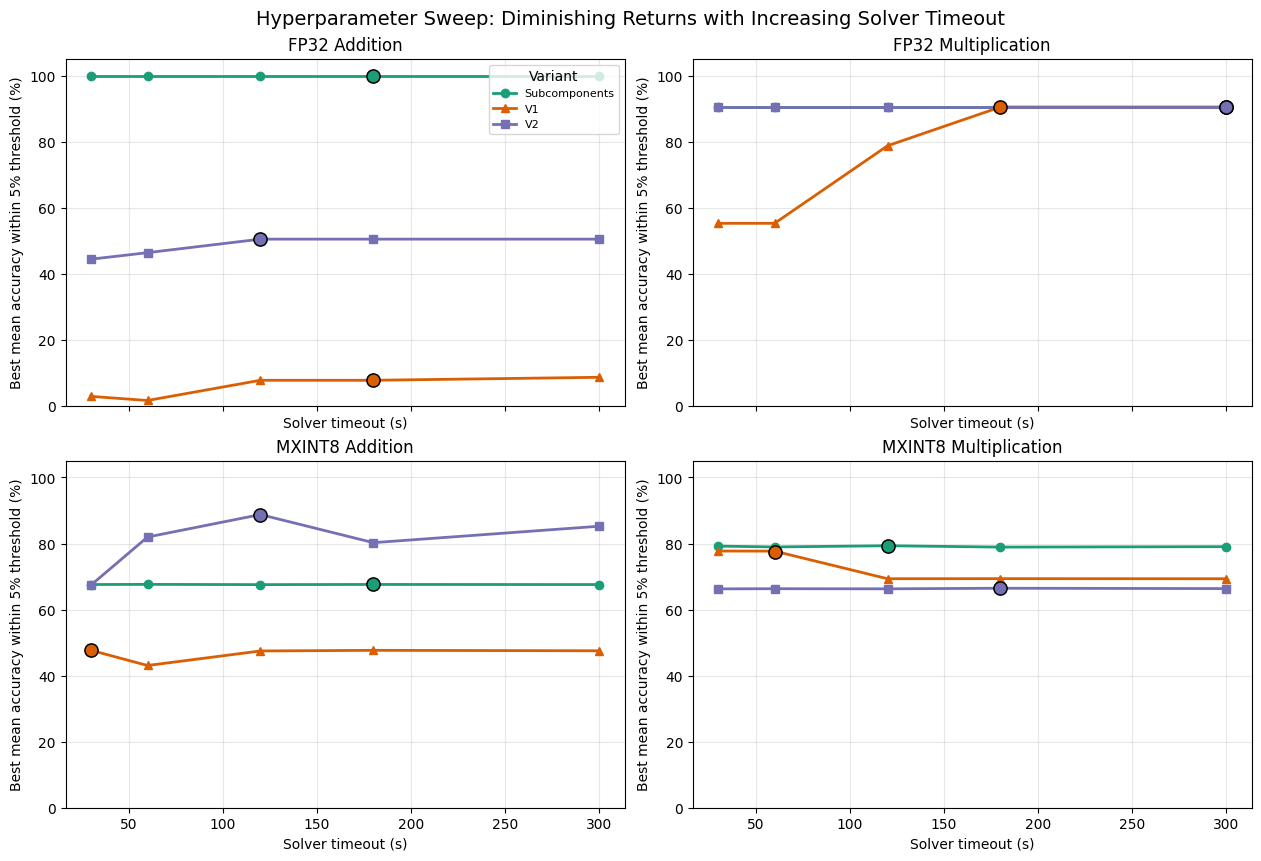

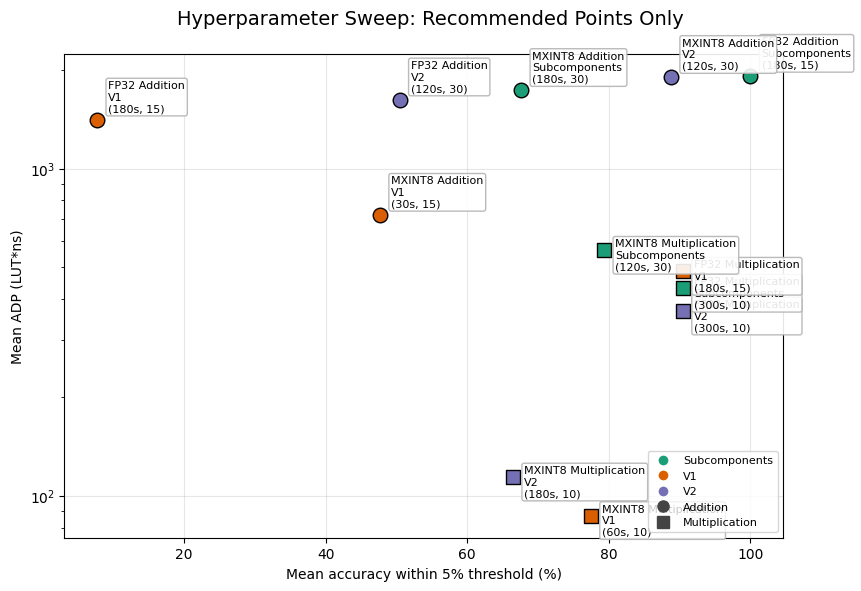

In [20]:
# Hyperparameter Sweep Analysis
# Leave blank to auto-pick the newest hyperparameter sweep output directory.
HP_OUTPUT_DIR = ""

import importlib
import src.Experiments.hyperparameter_notebook_analysis as _hp_analysis

# Force reload so notebook reruns pick up helper edits without requiring a kernel restart.
_hp_analysis = importlib.reload(_hp_analysis)

_hp_results = _hp_analysis.run_hyperparameter_sweep_notebook_analysis(
    ROOT=ROOT,
    display_fn=display if "display" in globals() else None,
    hp_output_dir=HP_OUTPUT_DIR,
    pipeline_df=globals().get("merged"),
)
globals().update(_hp_results)


# 3. Grammar Comparison

Subcomponents vs V1 (broad monolithic) vs V2 (tight structural sketch).
Compares synthesis speed, hardware cost, and accuracy — derived from pipeline results (Section 1).

Grammar selection study: 36 runs loaded from /home/josephluke/Program-Synthesis-for-Efficient-ML/results/grammar_selection/runs.jsonl
Versions: ['Subcomponents', 'V1', 'V2']

Grammar Comparison: Subcomponents vs V1 (Broad) vs V2 (Tight Sketch)

Grammar-based summary


,Benchmark,Grammar,Mean Runtime (s),Mean Enum Terms,Grammar Productions,Branching NTs
0,FP32 Addition,Subcomponents,2.3,"12,069",68,17
1,FP32 Addition,V1,"4,720.9","15,797,784",51,14
2,FP32 Addition,V2,"1,615.1","1,879,983",34,13
3,FP32 Multiplication,Subcomponents,1.8,"5,797",90,23
4,FP32 Multiplication,V1,"2,622.7","1,509,084",77,18
5,FP32 Multiplication,V2,2.0,"10,523",47,8
6,MXINT8 Addition,Subcomponents,8.6,"56,262",51,11
7,MXINT8 Addition,V1,"4,949.5","3,535,615",52,15
8,MXINT8 Addition,V2,"1,369.1","1,928,382",34,14
9,MXINT8 Multiplication,Subcomponents,469.7,"81,495",51,14



Hardware/accuracy summary


,Benchmark,Grammar,Mean LUTs,Mean Fmax (MHz),Mean Latency (ns),Exact Match %,Within Rel %
0,FP32 Addition,Subcomponents,458.000000,239.177000,4.181000,65.6%,100.0%
1,FP32 Addition,V1,331.000000,133.316000,7.501000,9.4%,12.5%
2,FP32 Addition,V2,416.000000,239.292000,4.179000,30.4%,46.4%
3,FP32 Multiplication,Subcomponents,32.000000,74.355000,13.449000,90.5%,90.5%
4,FP32 Multiplication,V1,20.666667,104.637000,9.702333,61.1%,67.0%
5,FP32 Multiplication,V2,32.000000,87.283000,11.457000,90.5%,90.5%
6,MXINT8 Addition,Subcomponents,59.000000,34.050000,29.368600,—,67.6%
7,MXINT8 Addition,V1,49.666667,62.883000,15.927300,—,19.4%
8,MXINT8 Addition,V2,72.333333,41.962000,23.936567,—,86.1%
9,MXINT8 Multiplication,Subcomponents,51.000000,69.097000,14.855000,—,74.1%



LaTeX grammar table:

\begin{tabular}{llllrr}
\toprule
Benchmark & Grammar & Mean Runtime (s) & Mean Enum Terms & Grammar Productions & Branching NTs \\
\midrule
FP32 Addition & Subcomponents & 2.3 & 12,069 & 68 & 17 \\
FP32 Addition & V1 & 4,720.9 & 15,797,784 & 51 & 14 \\
FP32 Addition & V2 & 1,615.1 & 1,879,983 & 34 & 13 \\
FP32 Multiplication & Subcomponents & 1.8 & 5,797 & 90 & 23 \\
FP32 Multiplication & V1 & 2,622.7 & 1,509,084 & 77 & 18 \\
FP32 Multiplication & V2 & 2.0 & 10,523 & 47 & 8 \\
MXINT8 Addition & Subcomponents & 8.6 & 56,262 & 51 & 11 \\
MXINT8 Addition & V1 & 4,949.5 & 3,535,615 & 52 & 15 \\
MXINT8 Addition & V2 & 1,369.1 & 1,928,382 & 34 & 14 \\
MXINT8 Multiplication & Subcomponents & 469.7 & 81,495 & 51 & 14 \\
MXINT8 Multiplication & V1 & 3,753.1 & 2,551,921 & 68 & 15 \\
MXINT8 Multiplication & V2 & 393.0 & 57,886,402 & 42 & 13 \\
\bottomrule
\end{tabular}


LaTeX hardware table:

\begin{tabular}{lllllll}
\toprule
Benchmark & Grammar & Mean LUTs & Mean Fmax (MH

,Label,Grammar Version,Num Subcomponents,Repetition,Accepted Constraints,Total Constraints,Solver Runtime Seconds Total,Enum Count Primary Total,Luts,Fmax Mhz,Latency Ns,Accuracy Exact Match,Within Rel Pct
0,FP32 Addition,Subcomponents,4,1,120.0,120.0,2.213740,10337.0,458.0,239.177,4.1810,0.6556,1.0000
1,FP32 Addition,Subcomponents,4,2,120.0,120.0,2.405710,12468.0,458.0,239.177,4.1810,0.6556,1.0000
2,FP32 Addition,Subcomponents,4,3,119.0,120.0,2.396122,13402.0,458.0,239.177,4.1810,0.6556,1.0000
3,FP32 Addition,V1,1,1,8.0,30.0,4746.584223,14716262.0,331.0,133.316,7.5010,0.1129,0.1501
4,FP32 Addition,V1,1,2,9.0,30.0,4672.175072,17958130.0,331.0,133.316,7.5010,0.1129,0.1501
5,FP32 Addition,V1,1,3,8.0,30.0,4743.990613,14718959.0,331.0,133.316,7.5010,0.0561,0.0752
6,FP32 Addition,V2,1,1,17.0,30.0,1035.521935,2999422.0,388.0,239.292,4.1790,0.3302,0.5045
7,FP32 Addition,V2,1,2,15.0,30.0,1537.436665,1549808.0,426.0,239.292,4.1790,0.2911,0.4454
8,FP32 Addition,V2,1,3,11.0,30.0,2272.241822,1090718.0,434.0,239.292,4.1790,0.2919,0.4407
9,FP32 Multiplication,Subcomponents,5,1,150.0,150.0,1.872835,5531.0,32.0,74.355,13.4490,0.9046,0.9046


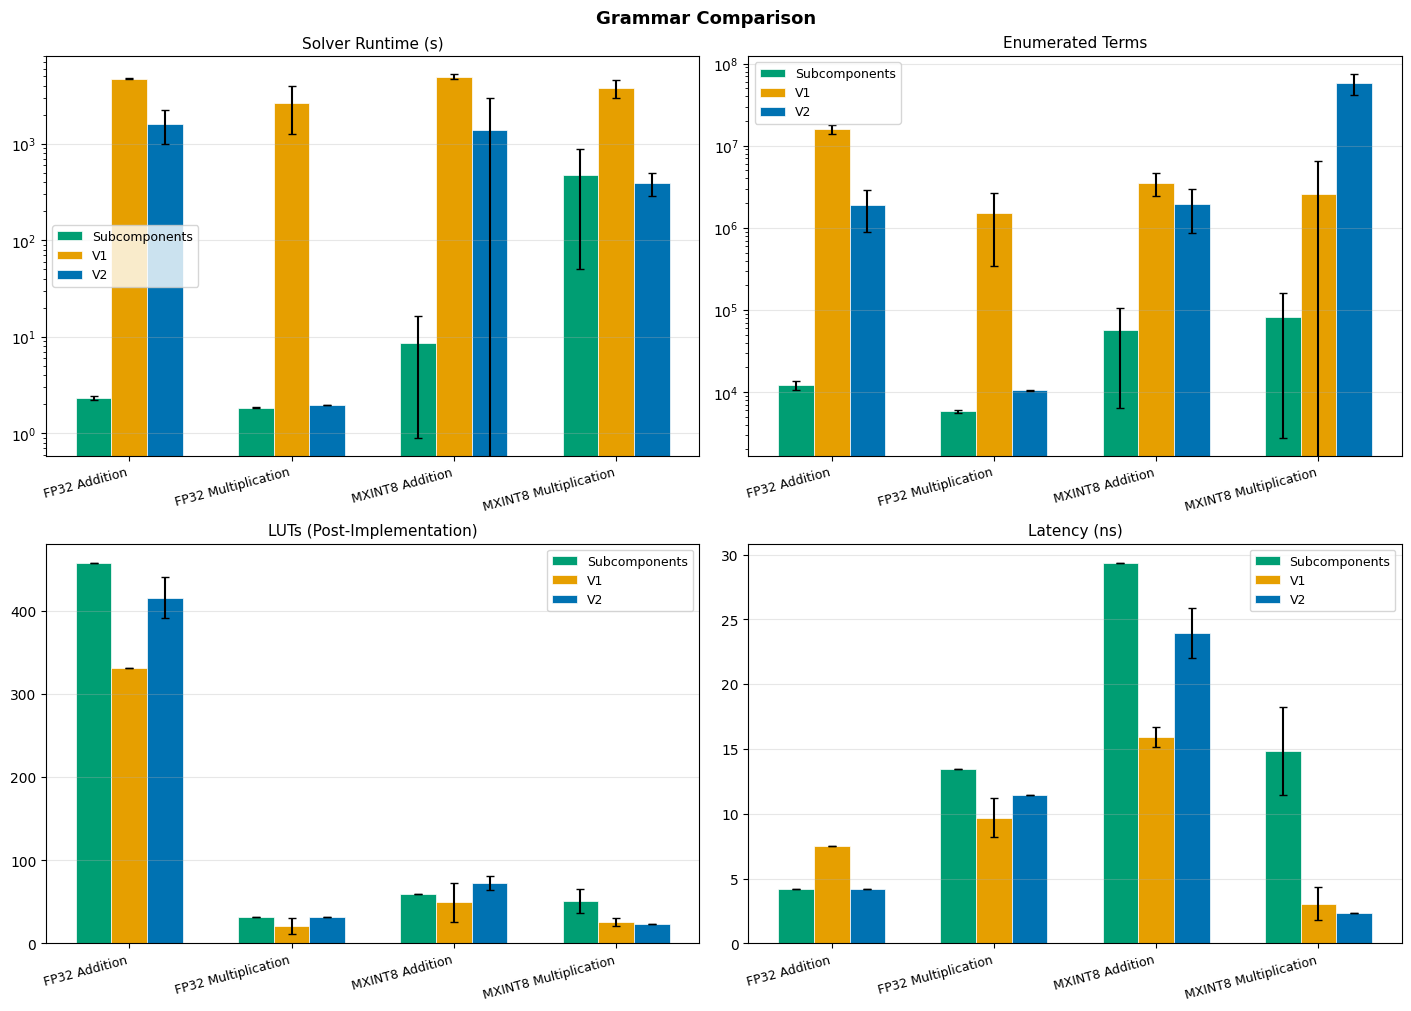


Cross-version runtime comparison


,Benchmark,V1 Runtime (s),V2 Runtime (s),Sub Runtime (s),V2 Speedup vs V1,Sub Speedup vs V1
0,FP32 Addition,"4,720.9","1,615.1",2.3,2.9x,"2,018.8x"
1,FP32 Multiplication,"2,622.7",2.0,1.8,"1,331.4x","1,420.5x"
2,MXINT8 Addition,"4,949.5","1,369.1",8.6,3.6x,573.2x
3,MXINT8 Multiplication,"3,753.1",393.0,469.7,9.5x,8.0x


In [21]:
# ──────── Grammar Comparison: Subcomponents vs V1 vs V2 ────────
# Prefer the dedicated grammar_selection study (includes grammar metrics like
# search space, production counts, enumeration stats, runtimes across reps).
# Falls back to pipeline `merged` DataFrame if grammar_selection not available.

if "merged" not in globals():
    raise RuntimeError("Run Section 1 first to populate merged dataframe.")

def _latest_grammar_selection_dir():
    candidates = []
    for p in (ROOT / "results").glob("**/runs.jsonl"):
        parent = p.parent
        name = parent.name.lower()
        if "grammar" not in name:
            continue
        if not (p.exists() and (parent / "summary.csv").exists()):
            continue
        try:
            mtime = max(p.stat().st_mtime, (parent / "summary.csv").stat().st_mtime)
        except OSError:
            continue
        candidates.append((mtime, parent))
    return max(candidates, key=lambda x: x[0])[1] if candidates else (ROOT / "results" / "grammar_selection")

GS_DIR = _latest_grammar_selection_dir()
gs_jsonl = GS_DIR / "runs.jsonl"

label_map = {
    "mxint8_add": "MXINT8 Addition", "mxint8_mul": "MXINT8 Multiplication",
    "fp32_add": "FP32 Addition", "fp32_mul": "FP32 Multiplication",
}

USE_GS = gs_jsonl.exists()

if USE_GS:
    # ── Load grammar selection study data ────────────────────────────────────
    gs_runs = [json.loads(line) for line in gs_jsonl.read_text().strip().split("\n")]
    gs_df = pd.DataFrame(gs_runs)

    for col in ["LUTs", "FFs", "Fmax_MHz", "Latency_ns", "accuracy_exact_match", "within_rel_pct",
                "solver_runtime_seconds_total", "enum_count_primary_total",
                "accepted_constraints", "total_constraints",
                "abs_err_avg", "abs_err_max", "abs_err_p99"]:
        if col in gs_df.columns:
            gs_df[col] = pd.to_numeric(gs_df[col], errors="coerce")
            gs_df.loc[gs_df[col] < 0, col] = np.nan

    gs_df["label"] = gs_df["benchmark"].map(label_map).fillna(gs_df["benchmark"])
    gs_df["LUT_equiv"] = gs_df["LUTs"].fillna(0) + gs_df.get("DSPs", pd.Series(0)).fillna(0) * 150
    gs_df["ADP"] = gs_df["LUT_equiv"] * gs_df["Latency_ns"]

    # Build summary directly from per-run data so all grammar versions present
    # in runs.jsonl are included, even if an older summary file is stale.
    group_cols = ["benchmark", "grammar_version"]
    agg_spec = {}
    for src, dst in [
        ("accepted_constraints", "mean_accepted_constraints"),
        ("total_constraints", "mean_total_constraints"),
        ("solver_runtime_seconds_total", "mean_runtime_seconds"),
        ("enum_count_primary_total", "mean_enum_count"),
        ("LUTs", "mean_LUTs"),
        ("FFs", "mean_FFs"),
        ("DSPs", "mean_DSPs"),
        ("Fmax_MHz", "mean_Fmax_MHz"),
        ("Latency_ns", "mean_Latency_ns"),
        ("accuracy_exact_match", "mean_accuracy_exact_match"),
        ("within_rel_pct", "mean_within_rel_pct"),
        ("abs_err_avg", "mean_abs_err_avg"),
        ("abs_err_max", "mean_abs_err_max"),
        ("abs_err_p99", "mean_abs_err_p99"),
    ]:
        if src in gs_df.columns:
            agg_spec[src] = "mean"

    gs_sdf = gs_df.groupby(group_cols).agg(agg_spec).reset_index() if agg_spec else gs_df[group_cols].drop_duplicates().copy()
    rename_map = {
        "accepted_constraints": "mean_accepted_constraints",
        "total_constraints": "mean_total_constraints",
        "solver_runtime_seconds_total": "mean_runtime_seconds",
        "enum_count_primary_total": "mean_enum_count",
        "LUTs": "mean_LUTs",
        "FFs": "mean_FFs",
        "DSPs": "mean_DSPs",
        "Fmax_MHz": "mean_Fmax_MHz",
        "Latency_ns": "mean_Latency_ns",
        "accuracy_exact_match": "mean_accuracy_exact_match",
        "within_rel_pct": "mean_within_rel_pct",
        "abs_err_avg": "mean_abs_err_avg",
        "abs_err_max": "mean_abs_err_max",
        "abs_err_p99": "mean_abs_err_p99",
    }
    gs_sdf = gs_sdf.rename(columns=rename_map)

    runs_col = gs_df.groupby(group_cols).size().rename("runs").reset_index()
    gs_sdf = gs_sdf.merge(runs_col, on=group_cols, how="left")

    for meta_col in ["num_subcomponents", "total_productions", "branching_nonterminals", "nonterminals", "search_space_proxy"]:
        if meta_col in gs_df.columns and meta_col not in gs_sdf.columns:
            meta = gs_df.groupby(group_cols)[meta_col].first().reset_index()
            gs_sdf = gs_sdf.merge(meta, on=group_cols, how="left")
        elif meta_col in gs_df.columns and meta_col in gs_sdf.columns:
            meta = gs_df.groupby(group_cols)[meta_col].first().reset_index()
            gs_sdf = gs_sdf.drop(columns=[meta_col]).merge(meta, on=group_cols, how="left")

    solve_successes = None
    if "solution_found" in gs_df.columns:
        solve_successes = gs_df.groupby(group_cols)["solution_found"].sum().rename("solve_successes").reset_index()
    elif "run_status" in gs_df.columns:
        solve_successes = gs_df.assign(_solved=gs_df["run_status"].eq("solved")).groupby(group_cols)["_solved"].sum().rename("solve_successes").reset_index()
    if solve_successes is not None:
        gs_sdf = gs_sdf.merge(solve_successes, on=group_cols, how="left")
        gs_sdf["solve_rate"] = gs_sdf["solve_successes"] / gs_sdf["runs"]

    gs_sdf["label"] = gs_sdf["benchmark"].map(label_map).fillna(gs_sdf["benchmark"])

    print(f"Grammar selection study: {len(gs_df)} runs loaded from {gs_jsonl}")
    versions_found = sorted(gs_df["grammar_version"].unique())
    print(f"Versions: {versions_found}")

    # ──── Aggregate summary tables ────
    grammar_cols = {
        "label": "Benchmark", "grammar_version": "Grammar",
        "mean_runtime_seconds": "Mean Runtime (s)",
        "mean_enum_count": "Mean Enum Terms",
        "total_productions": "Grammar Productions", "branching_nonterminals": "Branching NTs",
    }
    hardware_cols = {
        "label": "Benchmark", "grammar_version": "Grammar",
        "mean_LUTs": "Mean LUTs", "mean_Fmax_MHz": "Mean Fmax (MHz)",
        "mean_Latency_ns": "Mean Latency (ns)", "mean_accuracy_exact_match": "Exact Match %",
        "mean_within_rel_pct": "Within Rel %",
    }

    def _format_summary_table(df, cols_map):
        available = {k: v for k, v in cols_map.items() if k in df.columns}
        out = df[list(available.keys())].rename(columns=available).copy()
        if "Mean Runtime (s)" in out.columns:
            out["Mean Runtime (s)"] = out["Mean Runtime (s)"].map(lambda x: f"{x:,.1f}" if pd.notna(x) else "\u2014")
        if "Mean Enum Terms" in out.columns:
            out["Mean Enum Terms"] = out["Mean Enum Terms"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "\u2014")
        if "Mean LUTs" in out.columns:
            out["Mean LUTs"] = out["Mean LUTs"].map(lambda x: f"{x:.6f}" if pd.notna(x) else "\u2014")
        if "Mean Fmax (MHz)" in out.columns:
            out["Mean Fmax (MHz)"] = out["Mean Fmax (MHz)"].map(lambda x: f"{x:.6f}" if pd.notna(x) else "\u2014")
        if "Mean Latency (ns)" in out.columns:
            out["Mean Latency (ns)"] = out["Mean Latency (ns)"].map(lambda x: f"{x:.6f}" if pd.notna(x) else "\u2014")
        if "Exact Match %" in out.columns:
            out["Exact Match %"] = out["Exact Match %"].map(lambda x: f"{x*100:.1f}%" if pd.notna(x) and x <= 1.0 else (f"{x:.1f}%" if pd.notna(x) else "\u2014"))
        if "Within Rel %" in out.columns:
            out["Within Rel %"] = out["Within Rel %"].map(lambda x: f"{x*100:.1f}%" if pd.notna(x) and x <= 1.0 else (f"{x:.1f}%" if pd.notna(x) else "\u2014"))
        return out.sort_values(["Benchmark", "Grammar"]).reset_index(drop=True)

    grammar_tbl = _format_summary_table(gs_sdf, grammar_cols)
    hardware_tbl = _format_summary_table(gs_sdf, hardware_cols)

    print("\nGrammar Comparison: Subcomponents vs V1 (Broad) vs V2 (Tight Sketch)")
    print("=" * 90)
    print("\nGrammar-based summary")
    display(grammar_tbl)
    print("\nHardware/accuracy summary")
    display(hardware_tbl)

    # LaTeX export
    print("\nLaTeX grammar table:\n")
    print(grammar_tbl.to_latex(index=False, escape=True))
    print("\nLaTeX hardware table:\n")
    print(hardware_tbl.to_latex(index=False, escape=True))

    # ──── Per-run detail ────
    detail_cols = ["label", "grammar_version", "num_subcomponents", "repetition",
                   "accepted_constraints", "total_constraints",
                   "solver_runtime_seconds_total", "enum_count_primary_total",
                   "LUTs", "Fmax_MHz", "Latency_ns", "accuracy_exact_match", "within_rel_pct"]
    detail_cols = [c for c in detail_cols if c in gs_df.columns]
    detail = gs_df[detail_cols].sort_values(["label", "grammar_version", "repetition"]).reset_index(drop=True)
    detail.columns = [c.replace("_", " ").title() for c in detail.columns]
    print("\nPer-run detail")
    display(detail)

    # ──── Charts: Grouped bar comparison ────
    benchmarks = sorted(gs_df["label"].unique())
    versions = ["Subcomponents", "V1", "V2"]
    colours = {"Subcomponents": "#009E73", "V1": "#E69F00", "V2": "#0072B2"}

    chart_specs = [
        ("solver_runtime_seconds_total", "Solver Runtime (s)", True),
        ("enum_count_primary_total", "Enumerated Terms", True),
        ("LUTs", "LUTs (Post-Implementation)", False),
        ("Latency_ns", "Latency (ns)", False),
    ]
    active_specs = [(col, title, use_log) for col, title, use_log in chart_specs
                    if col in gs_df.columns and gs_df[col].notna().any()]

    n_charts = len(active_specs)
    if n_charts > 0:
        n_cols = min(n_charts, 2)
        n_rows = (n_charts + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows), constrained_layout=True)
        axes_flat = np.array(axes).flatten() if n_charts > 1 else [axes]

        for ax_idx, (col, title, use_log) in enumerate(active_specs):
            ax = axes_flat[ax_idx]
            x = np.arange(len(benchmarks))
            width = 0.22
            for i, ver in enumerate(versions):
                subset = gs_df[gs_df["grammar_version"] == ver]
                means = [subset[subset["label"] == b][col].mean() for b in benchmarks]
                stds  = [subset[subset["label"] == b][col].std()  for b in benchmarks]
                bar_h = [m if pd.notna(m) else 0 for m in means]
                bar_e = [s if pd.notna(s) else 0 for s in stds]
                offset = (i - 1) * width
                ax.bar(x + offset, bar_h, width, yerr=bar_e, label=ver,
                       color=colours[ver], capsize=3, edgecolor="white", linewidth=0.5)
            ax.set_xticks(x)
            ax.set_xticklabels(benchmarks, fontsize=9, rotation=15, ha="right")
            ax.set_title(title, fontsize=11)
            ax.legend(fontsize=9)
            ax.grid(axis="y", alpha=0.3)
            if use_log:
                ax.set_yscale("log")

        for ax_idx in range(len(active_specs), len(axes_flat)):
            axes_flat[ax_idx].set_visible(False)
        fig.suptitle("Grammar Comparison", fontsize=13, fontweight="bold")
        plt.show()

    # ──── Cross-version comparison table ────
    ratio_rows = []
    for bench in benchmarks:
        def _mean(ver, col):
            return gs_df[(gs_df["label"] == bench) & (gs_df["grammar_version"] == ver)][col].mean()
        rt1, rt2, rts = _mean("V1", "solver_runtime_seconds_total"), _mean("V2", "solver_runtime_seconds_total"), _mean("Subcomponents", "solver_runtime_seconds_total")
        en1, en2, ens = _mean("V1", "enum_count_primary_total"), _mean("V2", "enum_count_primary_total"), _mean("Subcomponents", "enum_count_primary_total")
        ratio_rows.append({
            "Benchmark": bench,
            "V1 Runtime (s)":    f"{rt1:,.1f}" if pd.notna(rt1) else "\u2014",
            "V2 Runtime (s)":    f"{rt2:,.1f}" if pd.notna(rt2) else "\u2014",
            "Sub Runtime (s)":   f"{rts:,.1f}" if pd.notna(rts) else "\u2014",
            "V2 Speedup vs V1":  f"{rt1/rt2:,.1f}x" if pd.notna(rt1) and pd.notna(rt2) and rt2 > 0 else "\u2014",
            "Sub Speedup vs V1": f"{rt1/rts:,.1f}x" if pd.notna(rt1) and pd.notna(rts) and rts > 0 else "\u2014",
        })
    if ratio_rows:
        print("\nCross-version runtime comparison")
        display(pd.DataFrame(ratio_rows))

else:
    # ── Fallback: derive from pipeline merged DataFrame ──────────────────────
    print("Grammar selection study not found — using pipeline results for grammar comparison.")
    gc = merged[merged["variant"].isin(["Subcomponents", "V1", "V2"])].copy()
    gc["label"] = gc.apply(lambda r: label_map.get(
        f"{'mxint8' if r['dtype']=='MXINT8' else 'fp32'}_{'add' if r['op']=='Addition' else 'mul'}",
        f"{r['dtype']} {r['op']}"), axis=1)

    summary_cols = {
        "label": "Benchmark", "variant": "Grammar",
        "LUTs": "LUTs", "FFs": "FFs", "DSPs": "DSPs",
        "Fmax_MHz": "Fmax (MHz)", "Latency_ns": "Latency (ns)",
        "ADP": "ADP (LUT·ns)", "within5pct": "Accuracy (%)",
    }
    available = {k: v for k, v in summary_cols.items() if k in gc.columns}
    tbl = gc[list(available.keys())].rename(columns=available).copy()
    for col, fmt in [("LUTs", ".0f"), ("FFs", ".0f"), ("DSPs", ".0f"),
                     ("Fmax (MHz)", ".1f"), ("Latency (ns)", ".2f"),
                     ("ADP (LUT·ns)", ".0f"), ("Accuracy (%)", ".1f")]:
        if col in tbl.columns:
            tbl[col] = tbl[col].apply(lambda x: f"{x:{fmt}}" if pd.notna(x) else "\u2014")
    tbl = tbl.sort_values(["Benchmark", "Grammar"]).reset_index(drop=True)
    print("\nGrammar Comparison (from pipeline results — no per-rep stats):")
    print("=" * 90)
    display(tbl)

    # Bar charts from pipeline data
    benchmarks = sorted(gc["label"].unique())
    versions = ["Subcomponents", "V1", "V2"]
    colours = {"Subcomponents": "#009E73", "V1": "#E69F00", "V2": "#0072B2"}
    for metric, title in [("LUTs", "LUTs"), ("Latency_ns", "Latency (ns)"), ("ADP", "ADP (LUT·ns)")]:
        if metric not in gc.columns or gc[metric].isna().all():
            continue
        fig, ax = plt.subplots(figsize=(10, 5))
        x = np.arange(len(benchmarks))
        width = 0.22
        for i, ver in enumerate(versions):
            subset = gc[gc["variant"] == ver]
            vals = [subset[subset["label"] == b][metric].values for b in benchmarks]
            means = [v[0] if len(v) > 0 and pd.notna(v[0]) else 0 for v in vals]
            offset = (i - 1) * width
            bars = ax.bar(x + offset, means, width, label=ver,
                          color=colours[ver], edgecolor="white", linewidth=0.5)
            ax.bar_label(bars, fmt="%.0f", fontsize=7, padding=2)
        ax.set_xticks(x)
        ax.set_xticklabels(benchmarks, fontsize=9, rotation=15, ha="right")
        ax.set_title(title, fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

# 4. Ablation Study

Factorial ablation measuring the contribution of each technique:
- **CVC5**: Our synthesiser's output vs FloPoCo's human-designed hardware
- **Relaxation**: Staged MSB constraint relaxation — applies to **monolithic grammars (V1, V2) only**
- **BV Search**: Bitvector width optimisation (mantissa truncation) — applies to **subcomponent grammar only**

> **Note:** Relaxation and BV Search are mutually exclusive — they apply to different grammar
> approaches. Relaxation operates during synthesis for monolithic solutions; BV Search
> post-processes the decomposed subcomponent solution.

| Config | Source | Grammar | Relaxation | BV Search |
|--------|--------|---------|------------|-----------|
| FloPoCo baseline | FloPoCo | — | — | — |
| FloPoCo + BV | FloPoCo | — | — | ✓ |
| CVC5 (Subcomponents) | CVC5 | Subcomponents | — | — |
| CVC5 (Subcomponents) + BV | CVC5 | Subcomponents | — | ✓ |
| CVC5 (V1) | CVC5 | V1 (monolithic) | — | — |
| CVC5 (V1) + Relaxation | CVC5 | V1 (monolithic) | ✓ | — |
| CVC5 (V2) | CVC5 | V2 (monolithic) | — | — |
| CVC5 (V2) + Relaxation | CVC5 | V2 (monolithic) | ✓ | — |


Ablation Study: Factorial Comparison


,Op,Dtype,Config,Grammar,Source,Relaxation,BV Search,LUTs,FFs,DSPs,Fmax_MHz,ADP (LUT·ns),Accuracy (%),Exact Match (%)
0,Addition,MXINT8,CVC5 (Sub),Subcomponents,CVC5,—,—,59.0,0.0,0.0,34.050,1732.7474,67.46,52.81
1,Addition,MXINT8,CVC5 (Sub) + BV,Subcomponents,CVC5,—,✓,54.0,0.0,0.0,NaN,NaN,100.00,NaN
2,Addition,MXINT8,CVC5 (V1),V1 (monolithic),CVC5,—,—,53.0,0.0,0.0,46.990,1127.8983,29.27,18.81
3,Addition,MXINT8,CVC5 (V1) + Relax,V1 (monolithic),CVC5,✓,—,41.0,0.0,0.0,64.029,640.3339,14.64,NaN
4,Addition,MXINT8,CVC5 (V2),V2 (monolithic),CVC5,—,—,26.0,0.0,0.0,69.425,374.5040,15.24,10.88
5,Addition,MXINT8,CVC5 (V2) + Relax,V2 (monolithic),CVC5,✓,—,69.0,0.0,0.0,45.869,1504.2828,89.15,NaN
6,Addition,FP32,FloPoCo + BV,—,FloPoCo,—,✓,401.0,247.0,0.0,NaN,NaN,100.00,100.00
7,Addition,FP32,CVC5 (Sub),Subcomponents,CVC5,—,—,458.0,0.0,0.0,239.177,1914.8980,100.00,65.56
8,Addition,FP32,CVC5 (Sub) + BV,Subcomponents,CVC5,—,✓,465.0,119.0,0.0,NaN,NaN,100.00,90.81
9,Addition,FP32,CVC5 (V1),V1 (monolithic),CVC5,—,—,331.0,0.0,0.0,133.316,2482.8310,15.01,11.29


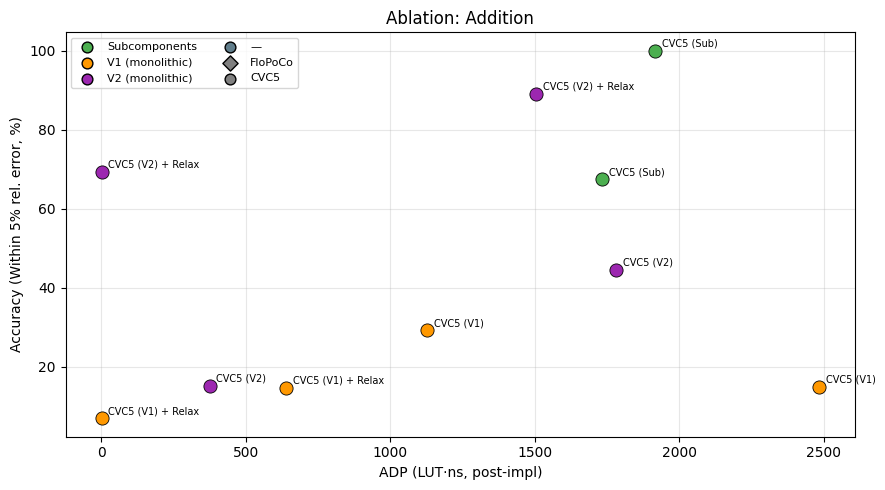

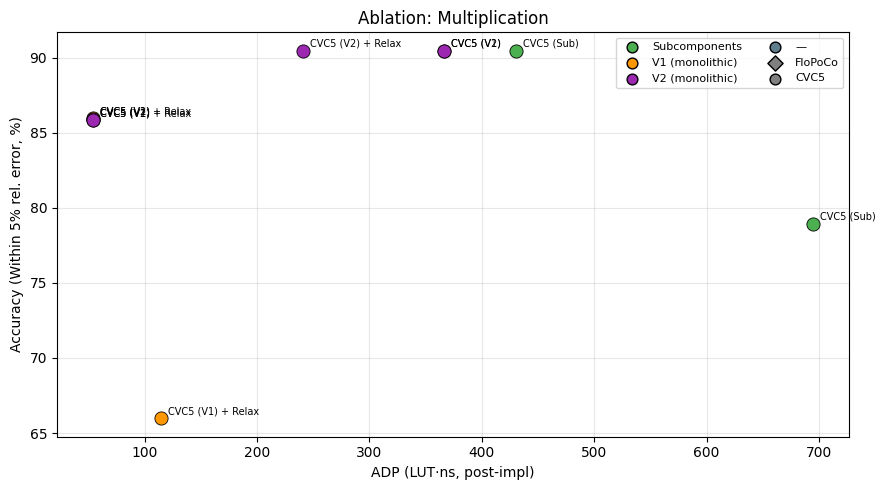

In [22]:
# ──────── Ablation Study: Factorial Table ────────
# Configs split by grammar track:
#   Subcomponents track: CVC5 (Sub)  →  CVC5 (Sub) + BV
#   Monolithic track:    CVC5 (V1)   →  CVC5 (V1) + Relaxation
#                        CVC5 (V2)   →  CVC5 (V2) + Relaxation
# Relaxation and BV Search are mutually exclusive — different grammar approaches.

if "merged" not in globals():
    raise RuntimeError("Run Section 1 first to populate merged dataframe.")

def _best_bv(bv_dataframe, family, target_name):
    """Return (LUTs, FFs, DSPs, within%, exact%) for the best BV sweep point, or NaNs."""
    if bv_dataframe is None or bv_dataframe.empty:
        return np.nan, np.nan, np.nan, np.nan, np.nan
    acc_col = "within_rel_pct" if "within_rel_pct" in bv_dataframe.columns else "accuracy_exact_match"
    mask = bv_dataframe["family"] == family
    if target_name:
        mask = mask & (bv_dataframe["target"] == target_name)
    subset = bv_dataframe[mask].dropna(subset=[acc_col, "LUTs"])
    if subset.empty:
        return np.nan, np.nan, np.nan, np.nan, np.nan
    best = subset.loc[subset[acc_col].idxmax()]
    acc_val = float(best[acc_col]) * 100 if float(best[acc_col]) <= 1.0 else float(best[acc_col])
    exact_val = best.get("accuracy_exact_match", np.nan)
    if pd.notna(exact_val) and exact_val <= 1.0:
        exact_val = float(exact_val) * 100
    return best.get("LUTs", np.nan), best.get("FFs", np.nan), best.get("DSPs", np.nan), acc_val, exact_val

# BV data (populated by Cell 19)
_bv = globals().get("bv_df", pd.DataFrame())

# Best relaxation-sweep result per (benchmark, variant, relax_mode)
# rsweep_df populated by Cell 15; falls back to pipeline row if absent.
_rsweep = globals().get("rsweep_df", pd.DataFrame())

def _best_relax(op, dtype, variant):
    """Return hardware row dict from best relaxation sweep result, or None."""
    if _rsweep.empty:
        return None
    bench = ("fp32_add" if (op == "Addition" and dtype == "FP32") else
             "fp32_mul" if (op == "Multiplication" and dtype == "FP32") else
             "mxint8_add" if (op == "Addition" and dtype == "MXINT8") else
             "mxint8_mul")
    sub = _rsweep[(_rsweep["benchmark"] == bench) & (_rsweep["variant"] == variant)
                  & (_rsweep["relax_mode"] == "staged")]
    sub = sub.dropna(subset=["adp_lut_ns"])
    if sub.empty:
        return None
    best = sub.loc[sub["adp_lut_ns"].idxmin()]
    return best.to_dict()

bv_targets = {
    ("Addition",       "MXINT8"): "mxint8_add",
    ("Addition",       "FP32"):   "fp32_add",
    ("Multiplication", "MXINT8"): "mxint8_mul",
    ("Multiplication", "FP32"):   "fp32_mul",
}

ablation_rows = []

for op in ["Addition", "Multiplication"]:
    for dtype in ["MXINT8", "FP32"]:
        bv_tgt = bv_targets.get((op, dtype), "")

        # ── FloPoCo baseline (FP32 only) ──────────────────────────────────────
        if dtype == "FP32":
            fp_row = merged[(merged["op"] == op) & (merged["dtype"] == dtype) & (merged["variant"] == "Flopoco")]
            if not fp_row.empty:
                r = fp_row.iloc[0]
                ablation_rows.append({
                    "Op": op, "Dtype": dtype, "Config": "FloPoCo",
                    "Grammar": "—", "Source": "FloPoCo", "Relaxation": "—", "BV Search": "—",
                    "LUTs": r.get("LUTs"), "FFs": r.get("FFs"), "DSPs": r.get("DSPs"),
                    "Fmax_MHz": r.get("Fmax_MHz"), "Latency_ns": r.get("Latency_ns"), "Accuracy (%)": r.get("within5pct"), "Exact Match (%)": r.get("exact_pct"),
                })

            bv_luts, bv_ffs, bv_dsps, bv_acc, bv_exact = _best_bv(_bv, "flopoco", bv_tgt)
            if not np.isnan(bv_acc):
                ablation_rows.append({
                    "Op": op, "Dtype": dtype, "Config": "FloPoCo + BV",
                    "Grammar": "—", "Source": "FloPoCo", "Relaxation": "—", "BV Search": "✓",
                    "LUTs": bv_luts, "FFs": bv_ffs, "DSPs": bv_dsps,
                    "Fmax_MHz": np.nan, "Accuracy (%)": bv_acc, "Exact Match (%)": bv_exact,
                })

        # ── Subcomponents track: CVC5 (Sub) and CVC5 (Sub) + BV ──────────────
        sub_row = merged[(merged["op"] == op) & (merged["dtype"] == dtype) & (merged["variant"] == "Subcomponents")]
        if not sub_row.empty:
            r = sub_row.iloc[0]
            ablation_rows.append({
                "Op": op, "Dtype": dtype, "Config": "CVC5 (Sub)",
                "Grammar": "Subcomponents", "Source": "CVC5", "Relaxation": "—", "BV Search": "—",
                "LUTs": r.get("LUTs"), "FFs": r.get("FFs"), "DSPs": r.get("DSPs"),
                "Fmax_MHz": r.get("Fmax_MHz"), "Latency_ns": r.get("Latency_ns"), "Accuracy (%)": r.get("within5pct"), "Exact Match (%)": r.get("exact_pct"),
            })

            bv_luts, bv_ffs, bv_dsps, bv_acc, bv_exact = _best_bv(_bv, "synthesised", bv_tgt)
            if not np.isnan(bv_acc):
                ablation_rows.append({
                    "Op": op, "Dtype": dtype, "Config": "CVC5 (Sub) + BV",
                    "Grammar": "Subcomponents", "Source": "CVC5", "Relaxation": "—", "BV Search": "✓",
                    "LUTs": bv_luts, "FFs": bv_ffs, "DSPs": bv_dsps,
                    "Fmax_MHz": np.nan, "Accuracy (%)": bv_acc, "Exact Match (%)": bv_exact,
                })

        # ── Monolithic track: V1 and V2, each with and without Relaxation ─────
        for variant_label in ["V1", "V2"]:
            v_row = merged[(merged["op"] == op) & (merged["dtype"] == dtype) & (merged["variant"] == variant_label)]
            if v_row.empty:
                continue
            r = v_row.iloc[0]
            ablation_rows.append({
                "Op": op, "Dtype": dtype, "Config": f"CVC5 ({variant_label})",
                "Grammar": f"{variant_label} (monolithic)", "Source": "CVC5", "Relaxation": "—", "BV Search": "—",
                "LUTs": r.get("LUTs"), "FFs": r.get("FFs"), "DSPs": r.get("DSPs"),
                "Fmax_MHz": r.get("Fmax_MHz"), "Latency_ns": r.get("Latency_ns"), "Accuracy (%)": r.get("within5pct"), "Exact Match (%)": r.get("exact_pct"),
            })

            # Relaxation: use best staged result from relaxation sweep if available,
            # otherwise fall back to the pipeline row (which was synthesised with relaxation).
            relax_result = _best_relax(op, dtype, variant_label)
            if relax_result is not None:
                _relax_acc = relax_result.get("within_rel_pct")
                if _relax_acc is not None and _relax_acc <= 1.0:
                    _relax_acc = _relax_acc * 100  # fraction → percentage
                _relax_exact = relax_result.get("accuracy_exact_match")
                if _relax_exact is not None and pd.notna(_relax_exact) and _relax_exact <= 1.0:
                    _relax_exact = _relax_exact * 100
                ablation_rows.append({
                    "Op": op, "Dtype": dtype, "Config": f"CVC5 ({variant_label}) + Relax",
                    "Grammar": f"{variant_label} (monolithic)", "Source": "CVC5", "Relaxation": "✓", "BV Search": "—",
                    "LUTs": relax_result.get("luts"), "FFs": relax_result.get("ffs"),
                    "DSPs": relax_result.get("dsps"), "Fmax_MHz": relax_result.get("fmax_mhz"), "Latency_ns": relax_result.get("latency_ns"),
                    "Accuracy (%)": _relax_acc, "Exact Match (%)": _relax_exact,
                })
            else:
                # Fallback: pipeline row (relaxation was applied during synthesis)
                ablation_rows.append({
                    "Op": op, "Dtype": dtype, "Config": f"CVC5 ({variant_label}) + Relax",
                    "Grammar": f"{variant_label} (monolithic)", "Source": "CVC5", "Relaxation": "✓ (pipeline)", "BV Search": "—",
                    "LUTs": r.get("LUTs"), "FFs": r.get("FFs"), "DSPs": r.get("DSPs"),
                    "Fmax_MHz": r.get("Fmax_MHz"), "Latency_ns": r.get("Latency_ns"), "Accuracy (%)": r.get("within5pct"), "Exact Match (%)": r.get("exact_pct"),
                    "_note": "relaxation sweep unavailable; using pipeline result",
                })

if not ablation_rows:
    print("No ablation data available. Run Section 1 first.")
else:
    abl_df = pd.DataFrame(ablation_rows)
    abl_df["LUT_equiv"] = abl_df["LUTs"].fillna(0) + abl_df["DSPs"].fillna(0) * 150
    # ADP = LUTs × Latency_ns, matching the sweep convention (DSPs not weighted).
    # Fall back to single-cycle estimate if Latency_ns unavailable.
    if "Latency_ns" in abl_df.columns and abl_df["Latency_ns"].notna().any():
        abl_df["ADP (LUT·ns)"] = (abl_df["LUTs"] * abl_df["Latency_ns"]).where(
            abl_df["Latency_ns"].notna())
    else:
        abl_df["ADP (LUT·ns)"] = (
            abl_df["LUTs"] * (1000.0 / abl_df["Fmax_MHz"].replace(0, np.nan))
        ).where(abl_df["Fmax_MHz"].notna())

    display_cols = ["Op", "Dtype", "Config", "Grammar", "Source", "Relaxation", "BV Search",
                    "LUTs", "FFs", "DSPs", "Fmax_MHz", "ADP (LUT·ns)", "Accuracy (%)", "Exact Match (%)"]
    display_cols = [c for c in display_cols if c in abl_df.columns]

    print("Ablation Study: Factorial Comparison")
    print("=" * 110)
    display(abl_df[display_cols].reset_index(drop=True))

    # ── Chart: ADP vs Accuracy per operation ──
    track_colors = {
        "Subcomponents": "#4CAF50",
        "V1 (monolithic)": "#FF9800",
        "V2 (monolithic)": "#9C27B0",
        "—": "#607D8B",
    }
    source_markers = {"FloPoCo": "D", "CVC5": "o"}
    dtype_hatches = {"MXINT8": "//", "FP32": ""}

    for op in ["Addition", "Multiplication"]:
        odf = abl_df[abl_df["Op"] == op].dropna(subset=["ADP (LUT·ns)", "Accuracy (%)"])
        if odf.empty:
            continue
        fig, ax = plt.subplots(figsize=(9, 5))
        for _, row in odf.iterrows():
            color = track_colors.get(str(row.get("Grammar", "—")), "gray")
            marker = source_markers.get(row["Source"], "x")
            ax.scatter(row["ADP (LUT·ns)"], row["Accuracy (%)"],
                       marker=marker, color=color, s=90,
                       edgecolors="black", linewidth=0.6, zorder=5)
            ax.annotate(row["Config"], (row["ADP (LUT·ns)"], row["Accuracy (%)"]),
                        fontsize=7, xytext=(5, 3), textcoords="offset points")
        for grammar, c in track_colors.items():
            ax.scatter([], [], color=c, marker="o", label=grammar, edgecolors="black", s=60)
        for src, m in source_markers.items():
            ax.scatter([], [], color="gray", marker=m, label=src, edgecolors="black", s=60)
        ax.set_xlabel("ADP (LUT·ns, post-impl)")
        ax.set_ylabel("Accuracy (Within 5% rel. error, %)")
        ax.set_title(f"Ablation: {op}")
        ax.legend(fontsize=8, ncol=2)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


## 4b. Constraint Relaxation Analysis

[Relaxation] Using latest run group 'run1'
[OK] /home/josephluke/Program-Synthesis-for-Efficient-ML/results/relaxation_sweep/run1_normal_full/runs.jsonl: 135 rows (mode=normal_full)
[OK] /home/josephluke/Program-Synthesis-for-Efficient-ML/results/relaxation_sweep/run1_wide/runs.jsonl: 135 rows (mode=wide)
[OK] /home/josephluke/Program-Synthesis-for-Efficient-ML/results/relaxation_sweep/run1_small/runs.jsonl: 135 rows (mode=small)

Total displayed: 336 runs across 3 cocotb mode(s)


cocotb_mode         normal_full  small  wide
benchmark  variant                          
fp32_add   V1                18     18    18
           V2                15     15    15
fp32_mul   V1                18     18    18
           V2                15     15    15
mxint8_add V1                18     18     0
           V2                18     18     0
mxint8_mul V1                18     18     0
           V2                15     15     0

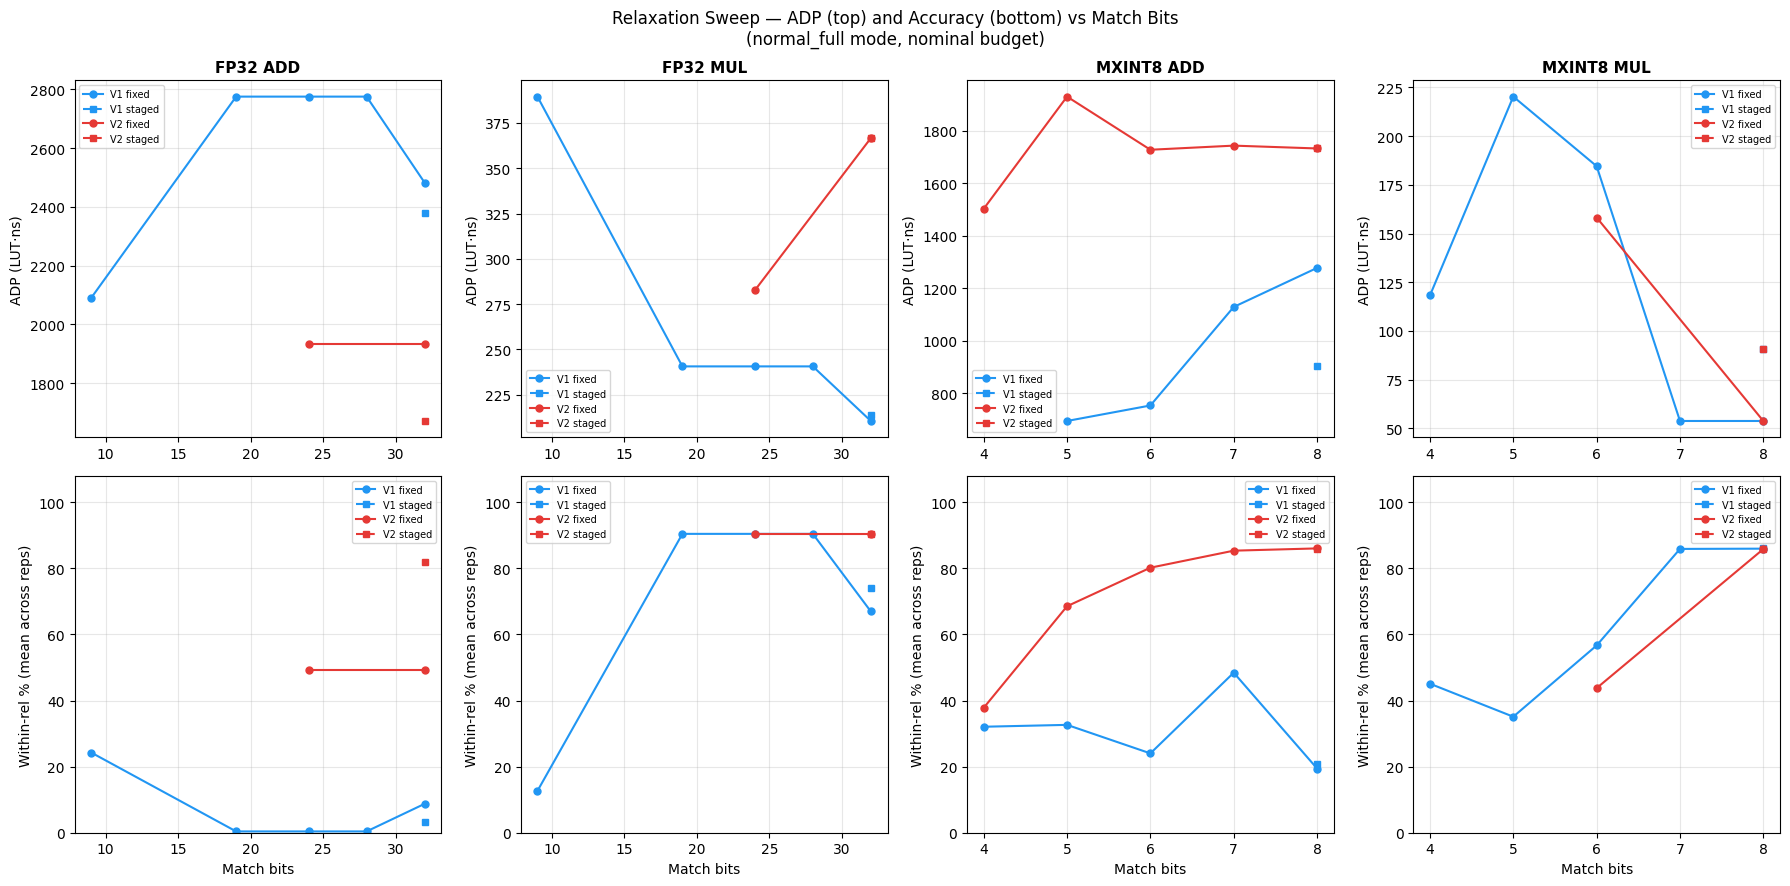

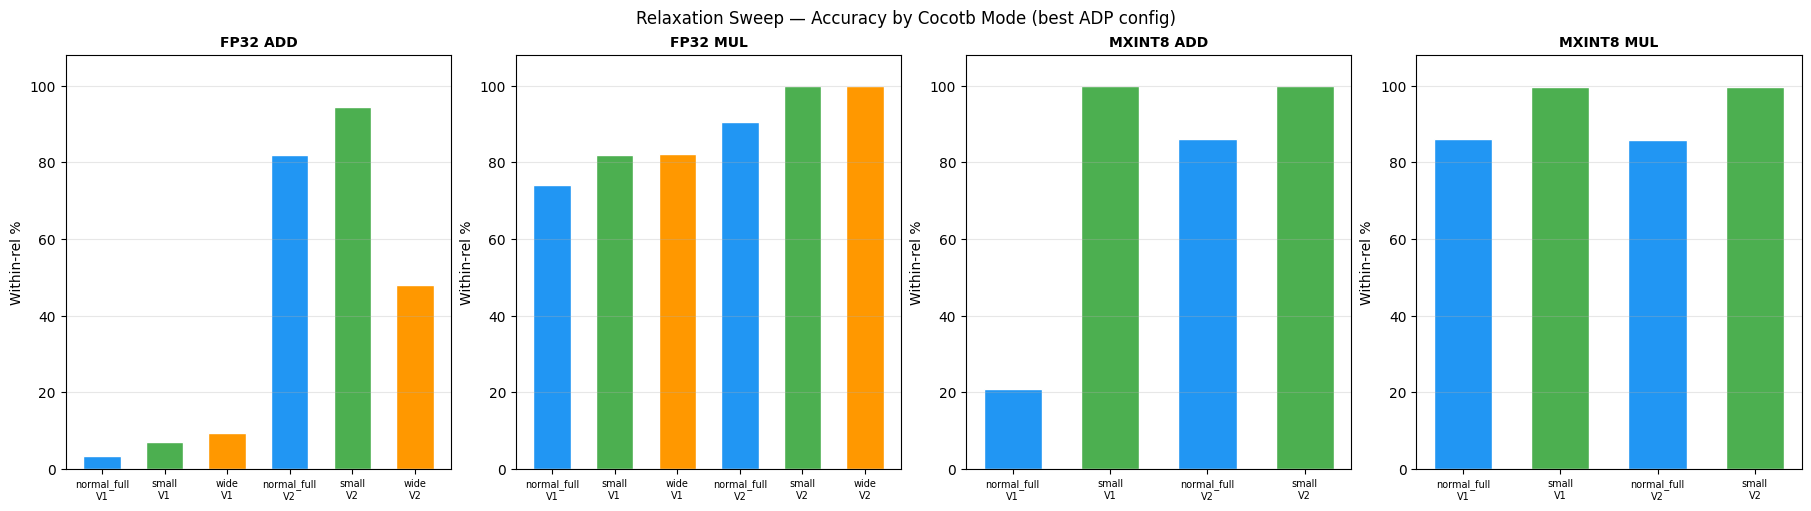

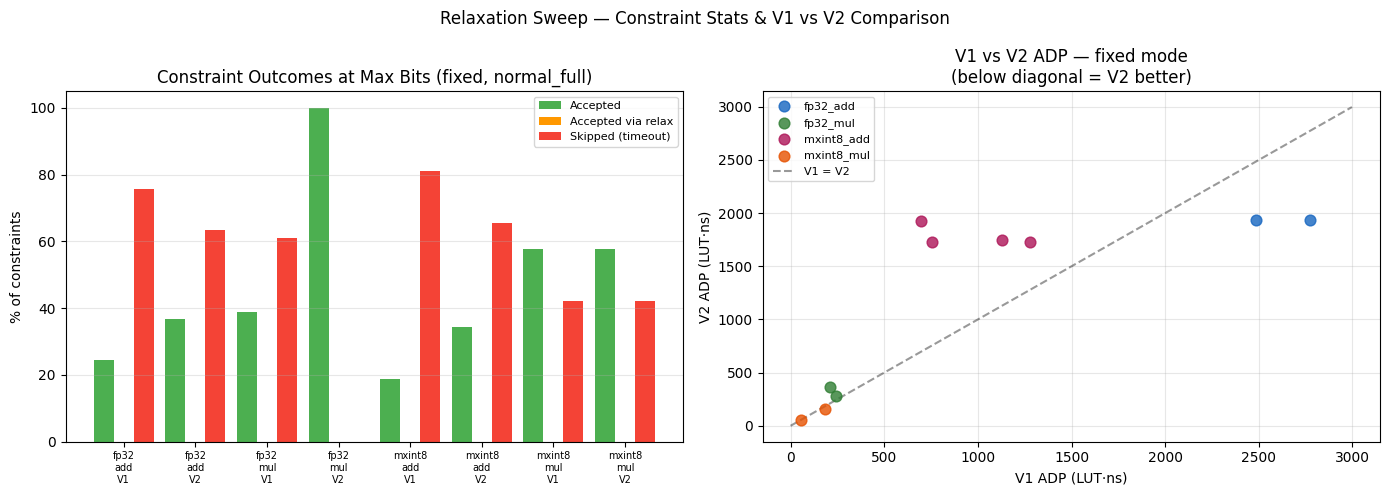


Best ADP configuration per benchmark/variant (mean across reps, normal_full):


,benchmark,variant,relax_mode,match_bits,LUTs,Fmax_MHz,ADP,Within%,Accept%,Skip%
0,fp32_add,V1,fixed,9,90.0,52.7,2090.4,24.3,32.2,67.8
1,fp32_add,V2,staged,32,400.0,239.3,1671.6,81.8,54.4,45.6
2,fp32_mul,V1,fixed,32,20.7,104.6,210.5,67.0,38.9,61.1
3,fp32_mul,V2,fixed,24,24.7,87.3,282.6,90.5,100.0,0.0
4,mxint8_add,V1,fixed,5,43.0,61.8,695.2,32.6,38.9,61.1
5,mxint8_add,V2,fixed,4,67.0,44.7,1502.7,37.8,46.7,53.3
6,mxint8_mul,V1,fixed,7,23.0,427.4,53.8,85.9,57.8,42.2
7,mxint8_mul,V2,fixed,8,23.0,427.4,53.8,85.9,57.8,42.2


In [23]:
# ──────── Relaxation Sweep Analysis (runs.jsonl) ────────
# Reads the newest relaxation sweep run group under results/relaxation_sweep/.
# Shows hardware quality (ADP, LUTs, Fmax), accuracy (within_rel_pct),
# and constraint stats across benchmarks, variants (V1/V2), relaxation modes
# (fixed/staged), bit levels, and cocotb operand modes (normal_full/small/wide).

RELAX_BASE = ROOT / "results" / "relaxation_sweep"
RELAX_MODES = ["normal_full", "small", "wide", "bits"]

def _split_relax_dir_name(name: str):
    for _mode in RELAX_MODES:
        _suffix = f"_{_mode}"
        if name.endswith(_suffix):
            return name[:-len(_suffix)], _mode
    return None, None

_relax_groups = {}
for _jsonl in RELAX_BASE.glob("*/runs.jsonl"):
    _prefix, _mode = _split_relax_dir_name(_jsonl.parent.name)
    if _prefix is None:
        continue
    _relax_groups.setdefault(_prefix, []).append((_mode, _jsonl))

rsweep_frames = []
if _relax_groups:
    _best_prefix, _best_entries = max(
        _relax_groups.items(),
        key=lambda kv: max(p.stat().st_mtime for _, p in kv[1])
    )
    print(f"[Relaxation] Using latest run group '{_best_prefix}'")
    for mode, jsonl_path in sorted(_best_entries, key=lambda x: x[1].stat().st_mtime, reverse=True):
        rows = [json.loads(l) for l in jsonl_path.read_text().strip().splitlines() if l.strip()]
        for r in rows:
            r["cocotb_mode"] = mode
            r["_source_run_dir"] = str(jsonl_path.parent)
        rsweep_frames.extend(rows)
        print(f"[OK] {jsonl_path}: {len(rows)} rows (mode={mode})")

# Also check legacy single-dir layout as fallback
if not rsweep_frames:
    legacy_candidates = sorted(RELAX_BASE.glob("*/runs.jsonl"), key=lambda p: p.stat().st_mtime, reverse=True)
    for legacy in legacy_candidates:
        rows = [json.loads(l) for l in legacy.read_text().strip().splitlines() if l.strip()]
        if not rows:
            continue
        for r in rows:
            r["cocotb_mode"] = r.get("cocotb_mode", "normal_full")
            r["_source_run_dir"] = str(legacy.parent)
        rsweep_frames.extend(rows)
        print(f"[OK] Legacy fallback: {legacy} ({len(rows)} rows)")
        break

if not rsweep_frames:
    print(f"No relaxation sweep results found under {RELAX_BASE}")
    rsweep_df = pd.DataFrame()
else:
    rsweep_df = pd.DataFrame(rsweep_frames)

    # Recover exact-match from raw cocotb logs when available.
    def _relax_log_tag(row):
        _budget_tag = "_stress" if row.get("budget") == "stress" else ""
        _mode_tag = "staged" if row.get("relax_mode") == "staged" else f"{int(row.get('match_bits'))}b"
        return f"{row.get('benchmark')}_{str(row.get('variant', '')).lower()}_{_mode_tag}{_budget_tag}_r{int(row.get('repetition', 0)):02d}"

    def _parse_exact_from_relax_log(log_path):
        try:
            text = Path(log_path).read_text()
        except Exception:
            return np.nan
        m = re.search(r"Exact match(?: \(quantized oracle\))?:\s*([0-9.]+)%", text)
        return float(m.group(1)) / 100.0 if m else np.nan

    if "accuracy_exact_match" not in rsweep_df.columns:
        rsweep_df["accuracy_exact_match"] = np.nan
    for _idx, _row in rsweep_df.iterrows():
        if pd.notna(_row.get("accuracy_exact_match", np.nan)):
            continue
        _run_dir = _row.get("_source_run_dir", "")
        if not _run_dir:
            continue
        _tag = _relax_log_tag(_row)
        _log_path = Path(_run_dir) / "raw" / f"{_tag}.log"
        rsweep_df.at[_idx, "accuracy_exact_match"] = _parse_exact_from_relax_log(_log_path)

    # Replace sentinel -1 values with NaN
    sentinel_cols = ["luts", "ffs", "dsps", "fmax_mhz", "latency_ns", "adp_lut_ns",
                     "within_rel_pct", "accuracy_exact_match", "abs_err_avg", "abs_err_max",
                     "accepted_constraints", "true_skips", "accepted_used_relaxation",
                     "total_constraints", "wall_seconds"]
    for col in sentinel_cols:
        if col in rsweep_df.columns:
            rsweep_df[col] = pd.to_numeric(rsweep_df[col], errors="coerce")
            rsweep_df.loc[rsweep_df[col] < 0, col] = np.nan

    # Do not display MXINT8 wide-mode relaxation results: this operand regime
    # sits outside the native MXINT8 representable range and is therefore not
    # included in the dissertation-facing plots/tables.
    rsweep_display = rsweep_df[
        ~(
            rsweep_df["benchmark"].astype(str).str.startswith("mxint8")
            & (rsweep_df["cocotb_mode"] == "wide")
        )
    ].copy()

    # ── Completion summary ───────────────────────────────────────────────────
    print(f"\nTotal displayed: {len(rsweep_display)} runs across {rsweep_display['cocotb_mode'].nunique()} cocotb mode(s)")
    comp_tbl = rsweep_display.groupby(["cocotb_mode", "benchmark", "variant"]).size().reset_index(name="runs")
    display(comp_tbl.pivot_table(index=["benchmark", "variant"], columns="cocotb_mode",
                                 values="runs", fill_value=0, aggfunc="sum"))

    # ── Aggregate: mean across repetitions ──────────────────────────────────
    nominal = rsweep_display[rsweep_display.get("budget", pd.Series("nominal", index=rsweep_display.index)) != "stress"].copy() \
              if "budget" in rsweep_display.columns else rsweep_display.copy()

    GROUP = ["cocotb_mode", "benchmark", "variant", "relax_mode", "match_bits"]
    METRICS = ["luts", "fmax_mhz", "adp_lut_ns", "within_rel_pct", "accuracy_exact_match",
               "accepted_constraints", "true_skips", "accepted_used_relaxation",
               "total_constraints", "wall_seconds"]
    agg = nominal.groupby(GROUP)[[m for m in METRICS if m in nominal.columns]].mean().reset_index()
    agg["within_pct"]  = agg["within_rel_pct"] * 100
    if "accuracy_exact_match" in agg.columns:
        agg["exact_pct"] = agg["accuracy_exact_match"] * 100
    if "true_skips" in agg.columns and "total_constraints" in agg.columns:
        agg["skip_pct"]    = agg["true_skips"]              / agg["total_constraints"] * 100
        agg["accept_pct"]  = agg["accepted_constraints"]    / agg["total_constraints"] * 100
        agg["relaxed_pct"] = agg["accepted_used_relaxation"]/ agg["total_constraints"] * 100

    # ── Fig 1: ADP and Accuracy vs bit level per benchmark (normal_full mode) ──
    BENCHES = [b for b in ["fp32_add", "fp32_mul", "mxint8_add", "mxint8_mul"]
               if b in agg["benchmark"].values]
    V_COLORS  = {"V1": "#2196F3", "V2": "#E53935"}
    M_STYLES  = {"fixed": "-",    "staged": "--"}
    M_MARKERS = {"fixed": "o",    "staged": "s"}

    agg_nf = agg[agg["cocotb_mode"] == "normal_full"] if "normal_full" in agg["cocotb_mode"].values else agg
    n_bench = max(len(BENCHES), 1)

    fig, axes = plt.subplots(2, n_bench, figsize=(4.5 * n_bench, 9),
                             squeeze=False)
    for col, bench in enumerate(BENCHES):
        ax_adp = axes[0, col]
        ax_acc = axes[1, col]
        bdf = agg_nf[agg_nf["benchmark"] == bench]
        for var in ["V1", "V2"]:
            for mode in ["fixed", "staged"]:
                sub = bdf[(bdf["variant"] == var) & (bdf["relax_mode"] == mode)].sort_values("match_bits")
                if sub.empty:
                    continue
                kw = dict(color=V_COLORS[var], linestyle=M_STYLES[mode],
                          marker=M_MARKERS[mode], markersize=5, label=f"{var} {mode}")
                ax_adp.plot(sub["match_bits"], sub["adp_lut_ns"], **kw)
                ax_acc.plot(sub["match_bits"], sub["within_pct"], **kw)

        ax_adp.set_title(bench.replace("_", " ").upper(), fontsize=11, fontweight="bold")
        ax_adp.set_ylabel("ADP (LUT·ns)")
        ax_adp.legend(fontsize=7)
        ax_adp.grid(True, alpha=0.3)

        ax_acc.set_xlabel("Match bits")
        ax_acc.set_ylabel("Within-rel % (mean across reps)")
        ax_acc.set_ylim(0, 108)
        ax_acc.legend(fontsize=7)
        ax_acc.grid(True, alpha=0.3)

    fig.suptitle("Relaxation Sweep — ADP (top) and Accuracy (bottom) vs Match Bits\n"
                 "(normal_full mode, nominal budget)", fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Fig 2: Cross-mode accuracy comparison ───────────────────────────────
    # For each benchmark × variant, compare accuracy at the best ADP config across modes
    if rsweep_display["cocotb_mode"].nunique() > 1:
        fig, axes = plt.subplots(1, n_bench, figsize=(4.5 * n_bench, 5),
                                 squeeze=False, constrained_layout=True)
        MODE_COLORS = {"normal_full": "#2196F3", "small": "#4CAF50", "wide": "#FF9800"}
        for col_idx, bench in enumerate(BENCHES):
            ax = axes[0, col_idx]
            for var in ["V1", "V2"]:
                x_vals, y_vals, labels = [], [], []
                for mode in [m for m in ["normal_full", "small", "wide", "bits"] if m in agg["cocotb_mode"].astype(str).unique()]:
                    sub = agg[(agg["cocotb_mode"] == mode) & (agg["benchmark"] == bench)
                              & (agg["variant"] == var) & (agg["relax_mode"] == "staged")]
                    if sub.empty:
                        sub = agg[(agg["cocotb_mode"] == mode) & (agg["benchmark"] == bench)
                                  & (agg["variant"] == var)]
                    if sub.empty:
                        continue
                    best = sub.loc[sub["adp_lut_ns"].idxmin()] if sub["adp_lut_ns"].notna().any() else sub.iloc[0]
                    x_vals.append(mode)
                    y_vals.append(best["within_pct"])
                    labels.append(f"{var}")
                if x_vals:
                    ax.bar([f"{x}\n{var}" for x in x_vals], y_vals,
                           color=[MODE_COLORS.get(x, "gray") for x in x_vals],
                           edgecolor="white", width=0.6)
            ax.set_title(bench.replace("_", " ").upper(), fontsize=10, fontweight="bold")
            ax.set_ylabel("Within-rel %")
            ax.set_ylim(0, 108)
            ax.grid(axis="y", alpha=0.3)
            ax.tick_params(axis="x", labelsize=7)

        fig.suptitle("Relaxation Sweep — Accuracy by Cocotb Mode (best ADP config)", fontsize=12)
        plt.show()

    # ── Fig 3: Constraint outcomes + V1 vs V2 ADP scatter ───────────────────
    fig, (ax_bar, ax_scatter) = plt.subplots(1, 2, figsize=(14, 5))

    # Bar: acceptance / skip / relaxed at max bits (fixed, nominal, normal_full)
    max_fixed = (agg_nf[agg_nf["relax_mode"] == "fixed"]
                 .loc[agg_nf[agg_nf["relax_mode"] == "fixed"]
                      .groupby(["benchmark", "variant"])["match_bits"].idxmax()])
    max_fixed = max_fixed.copy()
    max_fixed["label"] = max_fixed["benchmark"].str.replace("_", "\n") + "\n" + max_fixed["variant"]
    max_fixed = max_fixed.sort_values(["benchmark", "variant"])
    x = np.arange(len(max_fixed))
    w = 0.28
    if "accept_pct" in max_fixed.columns:
        ax_bar.bar(x - w,   max_fixed["accept_pct"],  w, label="Accepted",             color="#4CAF50")
        ax_bar.bar(x,       max_fixed["relaxed_pct"], w, label="Accepted via relax",   color="#FF9800")
        ax_bar.bar(x + w,   max_fixed["skip_pct"],    w, label="Skipped (timeout)",    color="#F44336")
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(max_fixed["label"], fontsize=7)
    ax_bar.set_ylabel("% of constraints")
    ax_bar.set_title("Constraint Outcomes at Max Bits (fixed, normal_full)")
    ax_bar.legend(fontsize=8)
    ax_bar.grid(True, alpha=0.3, axis="y")

    # Scatter: V1 ADP vs V2 ADP at matching bit levels (normal_full)
    v1_fixed = agg_nf[(agg_nf["variant"] == "V1") & (agg_nf["relax_mode"] == "fixed")][
        ["benchmark", "match_bits", "adp_lut_ns", "within_pct"]].rename(
        columns={"adp_lut_ns": "adp_v1", "within_pct": "within_v1"})
    v2_fixed = agg_nf[(agg_nf["variant"] == "V2") & (agg_nf["relax_mode"] == "fixed")][
        ["benchmark", "match_bits", "adp_lut_ns", "within_pct"]].rename(
        columns={"adp_lut_ns": "adp_v2", "within_pct": "within_v2"})
    vv = v1_fixed.merge(v2_fixed, on=["benchmark", "match_bits"])
    if not vv.empty:
        bench_colors = {"fp32_add": "#1565C0", "fp32_mul": "#2E7D32",
                        "mxint8_add": "#AD1457", "mxint8_mul": "#E65100"}
        for bench in vv["benchmark"].unique():
            sub = vv[vv["benchmark"] == bench]
            ax_scatter.scatter(sub["adp_v1"], sub["adp_v2"],
                               c=bench_colors.get(bench, "grey"), label=bench,
                               s=60, alpha=0.8, zorder=3)
        lim = vv[["adp_v1", "adp_v2"]].max().max() * 1.08
        ax_scatter.plot([0, lim], [0, lim], "k--", alpha=0.4, label="V1 = V2")
        ax_scatter.set_xlabel("V1 ADP (LUT·ns)")
        ax_scatter.set_ylabel("V2 ADP (LUT·ns)")
        ax_scatter.set_title("V1 vs V2 ADP — fixed mode\n(below diagonal = V2 better)")
        ax_scatter.legend(fontsize=8)
        ax_scatter.grid(True, alpha=0.3)

    fig.suptitle("Relaxation Sweep — Constraint Stats & V1 vs V2 Comparison", fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Best config per benchmark/variant (lowest ADP, nominal, normal_full) ─
    best_idx = agg_nf.groupby(["benchmark", "variant"])["adp_lut_ns"].idxmin()
    best_cols = ["benchmark", "variant", "relax_mode", "match_bits",
                 "luts", "fmax_mhz", "adp_lut_ns", "within_pct"]
    if "accept_pct" in agg_nf.columns:
        best_cols += ["accept_pct", "skip_pct"]
    best = agg_nf.loc[best_idx][[c for c in best_cols if c in agg_nf.columns]].rename(
        columns={"luts": "LUTs", "fmax_mhz": "Fmax_MHz", "adp_lut_ns": "ADP",
                 "within_pct": "Within%", "accept_pct": "Accept%", "skip_pct": "Skip%"})
    print("\nBest ADP configuration per benchmark/variant (mean across reps, normal_full):")
    display(best.round(1).reset_index(drop=True))

[Relaxation] Using latest run group 'run1'
Pareto-optimal configurations per benchmark (mean across reps, normal_full, nominal):


,benchmark,variant,relax_mode,match_bits,LUTs,Fmax_MHz,Latency_ns,ADP,Within%,Accept%,Skip%
0,fp32_add,V1,fixed,9,59.666667,34.810333,15.151267,1393.280667,24.270000,32.222222,67.777778
1,fp32_add,V2,staged,32,400.000000,239.292000,4.179000,1671.600000,81.803333,54.444444,45.555556
2,fp32_mul,V1,fixed,32,20.666667,104.637000,9.702333,210.458000,66.980000,38.888889,61.111111
3,fp32_mul,V1,staged,32,18.666667,87.283000,11.457000,213.864000,74.140000,38.888889,61.111111
4,fp32_mul,V1,fixed,19,21.000000,87.283000,11.457000,240.597000,90.460000,48.888889,51.111111
5,fp32_mul,V1,fixed,24,21.000000,87.283000,11.457000,240.597000,90.460000,48.888889,51.111111
6,fp32_mul,V1,fixed,28,21.000000,87.283000,11.457000,240.597000,90.460000,48.888889,51.111111
7,mxint8_add,V1,fixed,8,49.666667,19.159333,4.937633,425.260133,19.436667,18.888889,81.111111
8,mxint8_add,V1,fixed,5,43.000000,40.894667,10.537067,463.155800,32.646667,38.888889,61.111111
9,mxint8_add,V1,fixed,7,62.000000,55.017333,18.286967,1129.227000,48.443333,18.888889,81.111111



LaTeX pareto table:

\begin{tabular}{lllrlllllll}
\toprule
benchmark & variant & relax_mode & match_bits & LUTs & Fmax_MHz & Latency_ns & ADP & Within% & Accept% & Skip% \\
\midrule
fp32_add & V1 & fixed & 9 & 59.7 & 34.8 & 15.2 & 1393.3 & 24.3 & 32.2 & 67.8 \\
fp32_add & V2 & staged & 32 & 400.0 & 239.3 & 4.2 & 1671.6 & 81.8 & 54.4 & 45.6 \\
fp32_mul & V1 & fixed & 19 & 21.0 & 87.3 & 11.5 & 240.6 & 90.5 & 48.9 & 51.1 \\
fp32_mul & V1 & fixed & 24 & 21.0 & 87.3 & 11.5 & 240.6 & 90.5 & 48.9 & 51.1 \\
fp32_mul & V1 & fixed & 28 & 21.0 & 87.3 & 11.5 & 240.6 & 90.5 & 48.9 & 51.1 \\
fp32_mul & V1 & fixed & 32 & 20.7 & 104.6 & 9.7 & 210.5 & 67.0 & 38.9 & 61.1 \\
fp32_mul & V1 & staged & 32 & 18.7 & 87.3 & 11.5 & 213.9 & 74.1 & 38.9 & 61.1 \\
mxint8_add & V1 & fixed & 5 & 43.0 & 40.9 & 10.5 & 463.2 & 32.6 & 38.9 & 61.1 \\
mxint8_add & V1 & fixed & 7 & 62.0 & 55.0 & 18.3 & 1129.2 & 48.4 & 18.9 & 81.1 \\
mxint8_add & V1 & fixed & 8 & 49.7 & 19.2 & 4.9 & 425.3 & 19.4 & 18.9 & 81.1 \\
mxint8_add

,benchmark,variant,relax_mode,match_bits,LUTs,Fmax_MHz,Latency_ns,ADP,Within%,Accept%,Skip%
0,fp32_add,V2,staged,32,400.000000,239.292,4.179000,1671.600000,81.803333,54.444444,45.555556
1,fp32_mul,V1,fixed,19,21.000000,87.283,11.457000,240.597000,90.460000,48.888889,51.111111
2,mxint8_add,V2,fixed,8,72.333333,41.962,23.936567,1732.362333,86.060000,34.444444,65.555556
3,mxint8_mul,V1,fixed,8,23.000000,427.350,2.340000,53.820000,85.983333,57.777778,42.222222


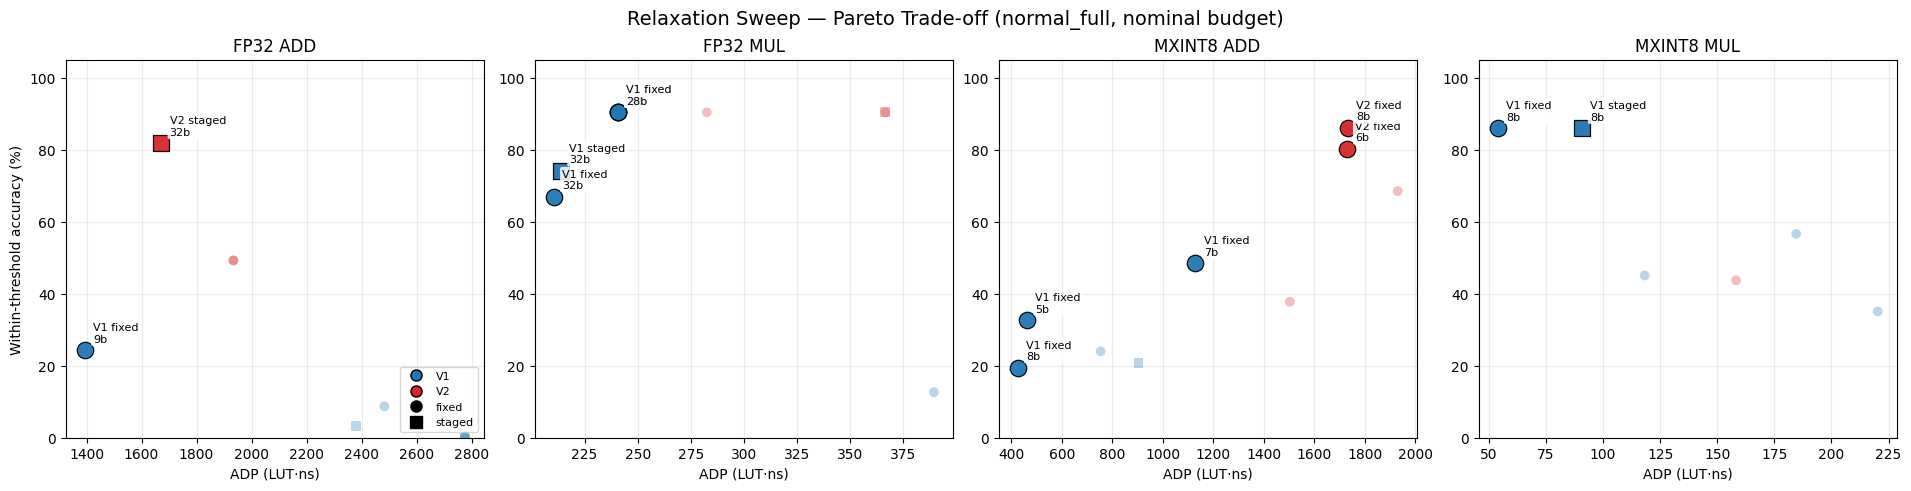

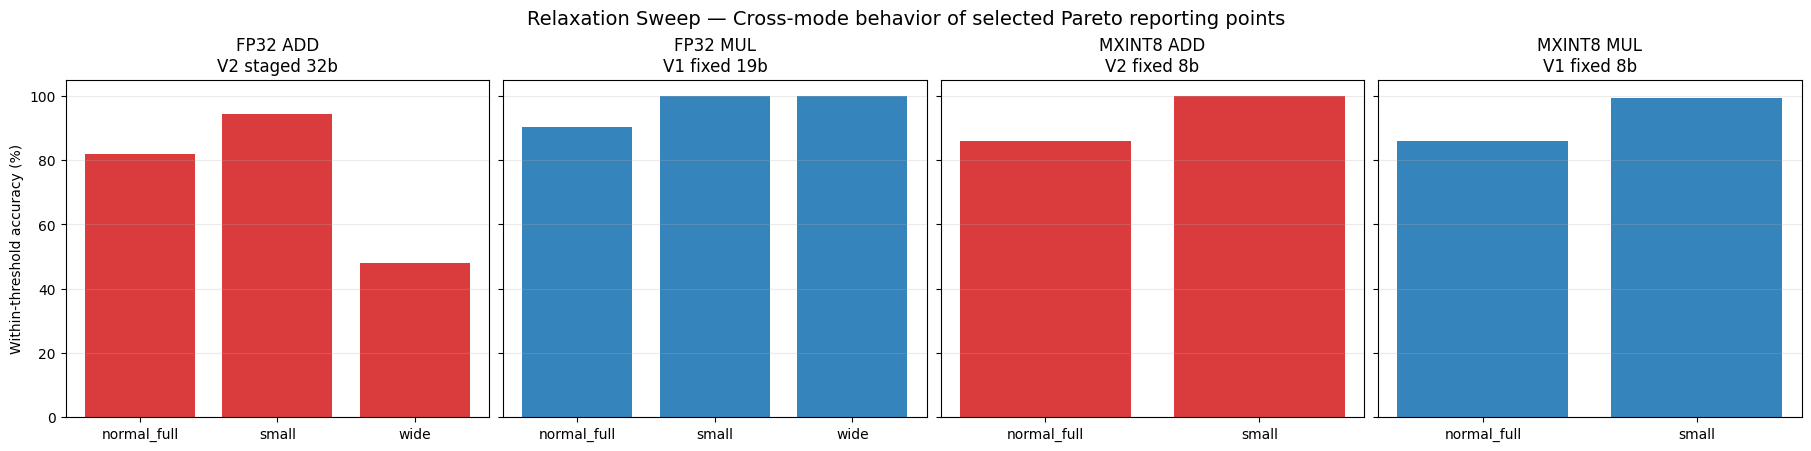


What is worth reporting from the actual Pareto results:


,benchmark,lowest_adp,highest_acc
0,FP32 ADD,"V1 fixed 9b @ ADP 1393.3, acc 24.3%","V2 staged 32b @ acc 81.8%, ADP 1671.6"
1,FP32 MUL,"V1 fixed 32b @ ADP 210.5, acc 67.0%","V1 fixed 19b @ acc 90.5%, ADP 240.6"
2,MXINT8 ADD,"V1 fixed 8b @ ADP 425.3, acc 19.4%","V2 fixed 8b @ acc 86.1%, ADP 1732.4"
3,MXINT8 MUL,"V1 fixed 8b @ ADP 53.8, acc 86.0%","V1 staged 8b @ acc 86.0%, ADP 90.6"


In [24]:
# ──────── 4b-ii. Relaxation Sweep Analysis (runs.jsonl, Pareto view) ────────
# Reads the newest relaxation sweep run group under results/relaxation_sweep/.
# Focuses the main analysis on Pareto trade-offs under the nominal normal_full regime,
# then shows how a representative Pareto point per benchmark generalizes across cocotb modes.

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

if "ROOT" not in globals():
    ROOT = Path.cwd()

RELAX_BASE = ROOT / "results" / "relaxation_sweep"
RELAX_MODES = ["normal_full", "small", "wide", "bits"]
RELAX_BENCH_ORDER = ["fp32_add", "fp32_mul", "mxint8_add", "mxint8_mul"]
RELAX_BENCH_LABELS = {
    "fp32_add": "FP32 ADD",
    "fp32_mul": "FP32 MUL",
    "mxint8_add": "MXINT8 ADD",
    "mxint8_mul": "MXINT8 MUL",
}
RELAX_VARIANT_COLORS = {"V1": "#1f77b4", "V2": "#d62728"}
RELAX_MODE_MARKERS = {"fixed": "o", "staged": "s"}


def _split_relax_dir_name(name: str):
    for _mode in RELAX_MODES:
        _suffix = f"_{_mode}"
        if name.endswith(_suffix):
            return name[:-len(_suffix)], _mode
    return None, None


_relax_groups = {}
for _jsonl in RELAX_BASE.glob("*/runs.jsonl"):
    _prefix, _mode = _split_relax_dir_name(_jsonl.parent.name)
    if _prefix is None:
        continue
    _relax_groups.setdefault(_prefix, []).append((_mode, _jsonl))

rsweep_frames = []
if _relax_groups:
    _best_prefix, _best_entries = max(
        _relax_groups.items(),
        key=lambda kv: max(p.stat().st_mtime for _, p in kv[1])
    )
    print(f"[Relaxation] Using latest run group '{_best_prefix}'")
    for _mode, _jsonl in sorted(_best_entries):
        _rows = [json.loads(line) for line in _jsonl.read_text().splitlines() if line.strip()]
        if not _rows:
            continue
        _df = pd.DataFrame(_rows)
        _df["cocotb_mode"] = _mode
        rsweep_frames.append(_df)
else:
    print("No relaxation sweep runs.jsonl files found.")

if not rsweep_frames:
    print("No relaxation sweep rows loaded.")
else:
    rsweep_df = pd.concat(rsweep_frames, ignore_index=True)

    # Hide MXINT8 wide in dissertation-facing analysis.
    rsweep_df = rsweep_df[~((rsweep_df["dtype"] == "MXINT8") & (rsweep_df["cocotb_mode"] == "wide"))].copy()

    num_cols = [
        "match_bits", "accepted_constraints", "total_constraints", "true_skips",
        "invalid_ground_truth_skips", "solver_attempts", "solver_runtime_seconds_total",
        "enum_count_primary_total", "wall_seconds", "luts", "ffs", "dsps", "fmax_mhz",
        "latency_ns", "adp_lut_ns", "within_rel_pct", "accuracy_exact_match"
    ]
    for _c in num_cols:
        if _c in rsweep_df.columns:
            rsweep_df[_c] = pd.to_numeric(rsweep_df[_c], errors="coerce")

    def _pctify(series: pd.Series) -> pd.Series:
        return series.where(series > 1.0, series * 100.0)

    GROUP = ["cocotb_mode", "benchmark", "dtype", "variant", "relax_mode", "budget", "match_bits"]
    agg_spec = {
        "n_reps": ("benchmark", "size"),
        "within_rel_pct": ("within_rel_pct", "mean"),
        "accepted_constraints": ("accepted_constraints", "mean"),
        "total_constraints": ("total_constraints", "mean"),
        "true_skips": ("true_skips", "mean"),
        "invalid_ground_truth_skips": ("invalid_ground_truth_skips", "mean"),
        "luts": ("luts", "mean"),
        "ffs": ("ffs", "mean"),
        "dsps": ("dsps", "mean"),
        "fmax_mhz": ("fmax_mhz", "mean"),
        "latency_ns": ("latency_ns", "mean"),
        "adp_lut_ns": ("adp_lut_ns", "mean"),
        "solver_runtime_total": ("solver_runtime_seconds_total", "mean"),
        "enum_count_total": ("enum_count_primary_total", "mean"),
    }
    if "accuracy_exact_match" in rsweep_df.columns:
        agg_spec["accuracy_exact_match"] = ("accuracy_exact_match", "mean")

    agg = rsweep_df.groupby(GROUP, dropna=False).agg(**agg_spec).reset_index()

    agg["within_pct"] = _pctify(agg["within_rel_pct"].astype(float))
    if "accuracy_exact_match" in agg.columns:
        agg["exact_pct"] = _pctify(agg["accuracy_exact_match"].astype(float))
        agg.loc[agg["accuracy_exact_match"].isna(), "exact_pct"] = np.nan
    else:
        agg["exact_pct"] = np.nan
    agg["accept_pct"] = 100.0 * agg["accepted_constraints"] / agg["total_constraints"].replace(0, np.nan)
    agg["skip_pct"] = 100.0 * agg["true_skips"] / agg["total_constraints"].replace(0, np.nan)

    nominal_nf = agg[(agg["budget"] == "nominal") & (agg["cocotb_mode"] == "normal_full")].copy()
    nominal_nf = nominal_nf[(nominal_nf["adp_lut_ns"] >= 0) & (nominal_nf["within_pct"] >= 0)].copy()

    def _pareto_mask(df: pd.DataFrame) -> np.ndarray:
        pts = df[["adp_lut_ns", "within_pct"]].to_numpy(dtype=float)
        mask = np.ones(len(df), dtype=bool)
        for i, (adp_i, acc_i) in enumerate(pts):
            dominated = False
            for j, (adp_j, acc_j) in enumerate(pts):
                if i == j:
                    continue
                if adp_j <= adp_i and acc_j >= acc_i and (adp_j < adp_i or acc_j > acc_i):
                    dominated = True
                    break
            mask[i] = not dominated
        return mask

    frontier_frames = []
    for _bench in RELAX_BENCH_ORDER:
        _sub = nominal_nf[nominal_nf["benchmark"] == _bench].copy()
        if _sub.empty:
            continue
        _sub["is_pareto"] = _pareto_mask(_sub)
        frontier_frames.append(_sub)
    frontier_df = pd.concat(frontier_frames, ignore_index=True) if frontier_frames else nominal_nf.iloc[0:0].copy()
    frontier_only = frontier_df[frontier_df["is_pareto"]].copy()

    frontier_table = frontier_only[[
        "benchmark", "variant", "relax_mode", "match_bits", "luts", "fmax_mhz",
        "latency_ns", "adp_lut_ns", "within_pct", "accept_pct", "skip_pct"
    ]].copy()
    frontier_table.columns = [
        "benchmark", "variant", "relax_mode", "match_bits", "LUTs", "Fmax_MHz",
        "Latency_ns", "ADP", "Within%", "Accept%", "Skip%"
    ]
    print("Pareto-optimal configurations per benchmark (mean across reps, normal_full, nominal):")
    display(frontier_table.sort_values(["benchmark", "ADP", "Within%"], ascending=[True, True, False]).reset_index(drop=True))

    _latex_df = frontier_table.copy()
    for _c in ["LUTs", "Fmax_MHz", "Latency_ns", "ADP", "Within%", "Accept%", "Skip%"]:
        _latex_df[_c] = _latex_df[_c].map(lambda x: f"{x:.1f}" if pd.notna(x) else "--")
    relax_pareto_latex = _latex_df.to_latex(index=False, escape=False)
    print("\nLaTeX pareto table:\n")
    print(relax_pareto_latex)

    # One reporting point per benchmark: lowest-ADP Pareto point within 1 percentage
    # point of that benchmark's maximum frontier accuracy.
    report_rows = []
    for _bench in RELAX_BENCH_ORDER:
        _sub = frontier_only[frontier_only["benchmark"] == _bench].copy()
        if _sub.empty:
            continue
        _max_acc = _sub["within_pct"].max()
        _near = _sub[_sub["within_pct"] >= (_max_acc - 1.0)].copy()
        _near = _near.sort_values(["adp_lut_ns", "within_pct", "match_bits"], ascending=[True, False, True])
        report_rows.append(_near.iloc[0])
    relax_report_df = pd.DataFrame(report_rows).reset_index(drop=True) if report_rows else frontier_only.iloc[0:0].copy()

    report_table = relax_report_df[[
        "benchmark", "variant", "relax_mode", "match_bits", "luts", "fmax_mhz",
        "latency_ns", "adp_lut_ns", "within_pct", "accept_pct", "skip_pct"
    ]].copy()
    report_table.columns = [
        "benchmark", "variant", "relax_mode", "match_bits", "LUTs", "Fmax_MHz",
        "Latency_ns", "ADP", "Within%", "Accept%", "Skip%"
    ]
    print("\nReporting point per benchmark (lowest-ADP Pareto point within 1 percentage point of max frontier accuracy):")
    display(report_table.reset_index(drop=True))

    fig, axes = plt.subplots(1, 4, figsize=(19, 4.8), constrained_layout=True, squeeze=False)
    for idx, _bench in enumerate(RELAX_BENCH_ORDER):
        ax = axes[0][idx]
        _sub = frontier_df[frontier_df["benchmark"] == _bench].copy()
        if _sub.empty:
            ax.set_visible(False)
            continue
        for _, row in _sub.iterrows():
            ax.scatter(
                row["adp_lut_ns"], row["within_pct"],
                color=RELAX_VARIANT_COLORS.get(str(row["variant"]), "gray"),
                marker=RELAX_MODE_MARKERS.get(str(row["relax_mode"]), "o"),
                s=140 if bool(row.get("is_pareto")) else 50,
                alpha=0.95 if bool(row.get("is_pareto")) else 0.30,
                edgecolors="black" if bool(row.get("is_pareto")) else "none",
                linewidth=0.9,
                zorder=3 if bool(row.get("is_pareto")) else 2,
            )
        for _, row in _sub[_sub["is_pareto"]].sort_values("adp_lut_ns").iterrows():
            ax.annotate(
                f"{row['variant']} {row['relax_mode']}\n{int(row['match_bits'])}b",
                (row["adp_lut_ns"], row["within_pct"]),
                xytext=(6, 6),
                textcoords="offset points",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.85),
            )
        ax.set_title(RELAX_BENCH_LABELS[_bench])
        ax.set_xlabel("ADP (LUT·ns)")
        ax.set_ylim(0, 105)
        ax.grid(alpha=0.25)
        if idx == 0:
            ax.set_ylabel("Within-threshold accuracy (%)")
    legend_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=RELAX_VARIANT_COLORS["V1"], markeredgecolor="black", markersize=8, label="V1"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=RELAX_VARIANT_COLORS["V2"], markeredgecolor="black", markersize=8, label="V2"),
        Line2D([0], [0], marker="o", color="black", linestyle="None", markersize=8, label="fixed"),
        Line2D([0], [0], marker="s", color="black", linestyle="None", markersize=8, label="staged"),
    ]
    axes[0][0].legend(handles=legend_handles, fontsize=8, loc="lower right")
    plt.suptitle("Relaxation Sweep — Pareto Trade-off (normal_full, nominal budget)", fontsize=14)
    plt.show()

    if not relax_report_df.empty:
        fig, axes = plt.subplots(1, 4, figsize=(18, 4.4), constrained_layout=True, squeeze=False, sharey=True)
        mode_order = ["normal_full", "small", "wide"]
        for idx, _bench in enumerate(RELAX_BENCH_ORDER):
            ax = axes[0][idx]
            sel = relax_report_df[relax_report_df["benchmark"] == _bench]
            if sel.empty:
                ax.set_visible(False)
                continue
            sel = sel.iloc[0]
            bars = []
            labels = []
            colors = []
            for _mode in mode_order:
                if _bench.startswith("mxint8") and _mode == "wide":
                    continue
                _match = agg[
                    (agg["benchmark"] == _bench)
                    & (agg["variant"] == sel["variant"])
                    & (agg["relax_mode"] == sel["relax_mode"])
                    & (agg["match_bits"] == sel["match_bits"])
                    & (agg["budget"] == sel["budget"])
                    & (agg["cocotb_mode"] == _mode)
                ]
                if _match.empty:
                    continue
                bars.append(float(_match.iloc[0]["within_pct"]))
                labels.append(_mode)
                colors.append(RELAX_VARIANT_COLORS.get(str(sel["variant"]), "gray"))
            ax.bar(labels, bars, color=colors, alpha=0.9)
            ax.set_title(f"{RELAX_BENCH_LABELS[_bench]}\n{sel['variant']} {sel['relax_mode']} {int(sel['match_bits'])}b")
            ax.set_ylim(0, 105)
            ax.grid(axis="y", alpha=0.25)
            if idx == 0:
                ax.set_ylabel("Within-threshold accuracy (%)")
        plt.suptitle("Relaxation Sweep — Cross-mode behavior of selected Pareto reporting points", fontsize=14)
        plt.show()

    noteworthy = []
    for _bench in RELAX_BENCH_ORDER:
        _sub = frontier_only[frontier_only["benchmark"] == _bench].sort_values(["adp_lut_ns", "within_pct"])
        if _sub.empty:
            continue
        _best_acc = _sub.loc[_sub["within_pct"].idxmax()]
        _best_cost = _sub.iloc[0]
        noteworthy.append({
            "benchmark": RELAX_BENCH_LABELS[_bench],
            "lowest_adp": f"{_best_cost['variant']} {_best_cost['relax_mode']} {_best_cost['match_bits']}b @ ADP {_best_cost['adp_lut_ns']:.1f}, acc {_best_cost['within_pct']:.1f}%",
            "highest_acc": f"{_best_acc['variant']} {_best_acc['relax_mode']} {_best_acc['match_bits']}b @ acc {_best_acc['within_pct']:.1f}%, ADP {_best_acc['adp_lut_ns']:.1f}",
        })
    noteworthy_df = pd.DataFrame(noteworthy)
    print("\nWhat is worth reporting from the actual Pareto results:")
    display(noteworthy_df)

# Bitvector Sweep

In [25]:
# ──────── Load Bitvector Sweep Results ────────
# Scans results/sweeps/ for summary CSVs from both synthesised and FloPoCo BV sweeps.
# Robust to different directory layouts (all-targets combined, per-target, per-mode).

PROD_SWEEPS_ROOT = ROOT / "results" / "sweeps"
frames = []
_seen_files: set[str] = set()

def _load_csv(path, family, default_mode=""):
    """Load a summary CSV, tag with family and cocotb_mode, deduplicate by file path."""
    key = str(path.resolve())
    if key in _seen_files:
        return
    _seen_files.add(key)
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"[WARN] Failed to read {path}: {e}")
        return
    if df.empty:
        return
    df["family"] = family
    # Use cocotb_mode from data if present, else from directory name or default
    if "cocotb_mode" not in df.columns:
        # Try to infer from parent directory name (e.g., "normal_full", "small", "wide")
        parent_name = path.parent.name.lower()
        if parent_name in ("normal_full", "small", "wide"):
            df["cocotb_mode"] = parent_name
        else:
            df["cocotb_mode"] = default_mode
    df["cocotb_mode_config"] = df["cocotb_mode"]
    df["rel_error_pct_config"] = pd.to_numeric(
        df["within_rel_threshold_pct"], errors="coerce"
    ) if "within_rel_threshold_pct" in df.columns else float("nan")
    df["run_dir"] = str(path.parent)
    frames.append(df)

# ── 1. Synthesised BV sweeps ────────────────────────────────────────────────
# Combined summaries from --all-targets mode
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("bitvector_all/summary_all_targets.csv")):
    _load_csv(csv_path, "synthesised")
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("bitvector_all/*/summary_all_targets.csv")):
    _load_csv(csv_path, "synthesised")

# Per-target summaries (single-target mode or per-mode subdirs)
synth_mode_csvs = sorted(PROD_SWEEPS_ROOT.glob("bitvector_all/*/summary.csv"))
if synth_mode_csvs:
    print(f"[BV] Using {len(synth_mode_csvs)} per-mode synthesised summaries from bitvector_all/*/")
    for csv_path in synth_mode_csvs:
        _load_csv(csv_path, "synthesised")
else:
    for csv_path in sorted(PROD_SWEEPS_ROOT.glob("bitvector_all/summary.csv")):
        _load_csv(csv_path, "synthesised")

# Legacy per-target directories: bitvector_{target}/
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("bitvector_*/summary.csv")):
    if "flopoco" in csv_path.parent.name or csv_path.parent.name == "bitvector_all":
        continue
    _load_csv(csv_path, "synthesised")

# Also check summary.json as fallback (same data, JSON format)
for json_path in sorted(PROD_SWEEPS_ROOT.glob("bitvector_all/**/summary.json")):
    key = str(json_path.resolve())
    csv_sibling = json_path.with_name("summary.csv")
    if str(csv_sibling.resolve()) in _seen_files:
        continue  # CSV already loaded
    if key in _seen_files:
        continue
    _seen_files.add(key)
    try:
        data = json.loads(json_path.read_text())
        if isinstance(data, list) and data:
            df = pd.DataFrame(data)
            df["family"] = "synthesised"
            if "cocotb_mode" not in df.columns:
                df["cocotb_mode"] = ""
            df["cocotb_mode_config"] = df["cocotb_mode"]
            df["rel_error_pct_config"] = pd.to_numeric(
                df["within_rel_threshold_pct"], errors="coerce"
            ) if "within_rel_threshold_pct" in df.columns else float("nan")
            df["run_dir"] = str(json_path.parent)
            frames.append(df)
    except Exception:
        pass

# ── 2. FloPoCo BV sweeps ───────────────────────────────────────────────────
# Covers runner outputs from per-target dirs and flopoco_bitvector_all combined dirs.
# Prefer impl dirs over non-impl dirs when both exist.
_flopoco_targets_with_impl: set[str] = set()

# Pass 0: combined all-target summaries
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("flopoco_bitvector_all/summary_all_targets.csv")):
    _load_csv(csv_path, "flopoco")
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("flopoco_bitvector_all/*/summary_all_targets.csv")):
    _load_csv(csv_path, "flopoco")

# Pass 1: impl mode-level subdirectories
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("flopoco_bitvector_impl_*/*/summary.csv")):
    _load_csv(csv_path, "flopoco")
    try:
        df = pd.read_csv(csv_path)
        if "target" in df.columns:
            _flopoco_targets_with_impl.update(df["target"].unique())
    except Exception:
        pass

# Pass 2: impl parent summaries (only if no mode-subdirectory)
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("flopoco_bitvector_impl_*/summary.csv")):
    _load_csv(csv_path, "flopoco")
    try:
        df = pd.read_csv(csv_path)
        if "target" in df.columns:
            _flopoco_targets_with_impl.update(df["target"].unique())
    except Exception:
        pass

# Pass 3: non-impl dirs (only for targets without impl data)
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("flopoco_bitvector_*/summary.csv")):
    if "impl" in csv_path.parent.name:
        continue
    try:
        df = pd.read_csv(csv_path)
        if "target" in df.columns and set(df["target"].unique()).issubset(_flopoco_targets_with_impl):
            continue
    except Exception:
        pass
    _load_csv(csv_path, "flopoco")

# ── 3. Build combined DataFrame ────────────────────────────────────────────
if not frames:
    print(f"No sweep summaries found under {PROD_SWEEPS_ROOT}")
    print("BV sweeps are deferred — launch them after pipeline sessions finish.")
    bv_df = pd.DataFrame()
else:
    bv_df = pd.concat(frames, ignore_index=True)

    # Deduplicate: same (target, cocotb_mode, mantissa_bits, family) = same experiment
    dedup_cols = [c for c in ["target", "cocotb_mode", "mantissa_bits", "exponent_bits", "family"]
                  if c in bv_df.columns]
    if dedup_cols:
        before = len(bv_df)
        bv_df = bv_df.drop_duplicates(subset=dedup_cols, keep="last")
        if before != len(bv_df):
            print(f"Deduplicated: {before} -> {len(bv_df)} rows")

    for col in ["mantissa_bits", "accuracy_exact_match", "within_rel_pct", "within_5pct_rel",
                "abs_err_avg", "abs_err_p99", "abs_err_max",
                "LUTs", "FFs", "DSPs", "BRAMs", "Fmax_MHz", "Latency_ns", "area_score",
                "adp_lut_ns", "rel_error_pct_config"]:
        if col in bv_df.columns:
            bv_df[col] = pd.to_numeric(bv_df[col], errors="coerce")
            bv_df.loc[bv_df[col] < 0, col] = np.nan

    print(f"Loaded {len(bv_df)} rows from {len(frames)} summaries")
    print("Families:", sorted(bv_df["family"].unique()))
    if "cocotb_mode" in bv_df.columns:
        print("Cocotb modes:", sorted(bv_df["cocotb_mode"].dropna().unique()))
    if "target" in bv_df.columns:
        print("Targets:", sorted(bv_df["target"].dropna().unique()))

[BV] Using 12 per-mode synthesised summaries from bitvector_all/*/
Loaded 306 rows from 18 summaries
Families: ['flopoco', 'synthesised']
Cocotb modes: ['normal_full', 'small', 'wide']
Targets: ['fp32_add', 'fp32_mul', 'mxint8_add', 'mxint8_mul']


Bitvector knee-point summary (Main text)
     Benchmark       Design         Mode  Threshold (%)  Knee Mantissa  \
6     FP32 Mul  Synthesised  normal_full           95.0              6   
7     FP32 Mul  Synthesised        small           95.0              6   
8     FP32 Mul  Synthesised         wide           95.0              6   
9     FP32 Mul      FloPoCo  normal_full           95.0              6   
10    FP32 Mul      FloPoCo        small           95.0              6   
11    FP32 Mul      FloPoCo         wide           95.0              6   
12  MXINT8 Add  Synthesised  normal_full           75.0              4   
13  MXINT8 Add  Synthesised        small           75.0              1   
14  MXINT8 Mul  Synthesised  normal_full           75.0              4   
15  MXINT8 Mul  Synthesised        small           75.0              1   

    Within-5%  Exact match   LUTs   FFs  Cycles  Latency (ns)       ADP  \
6       90.34         0.01   48.0   0.0     0.0         8.697   417.4

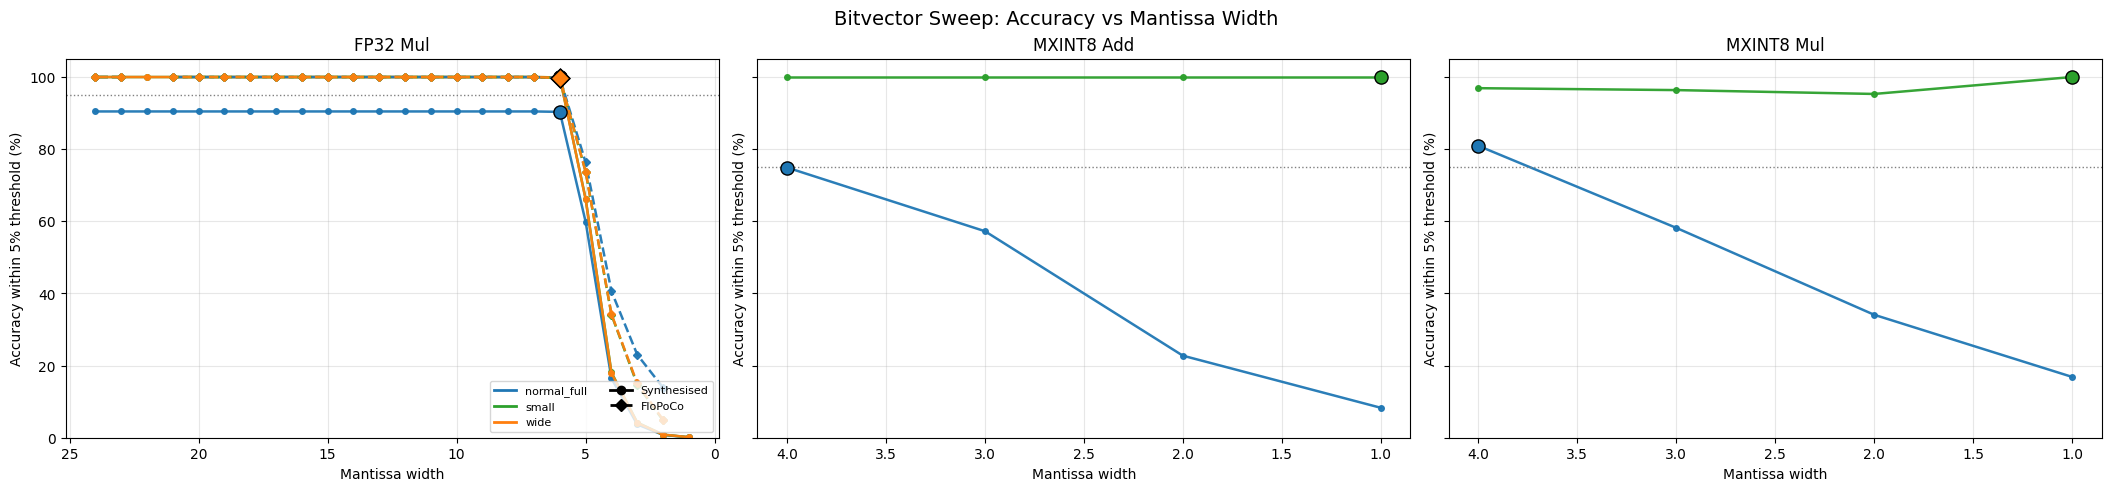

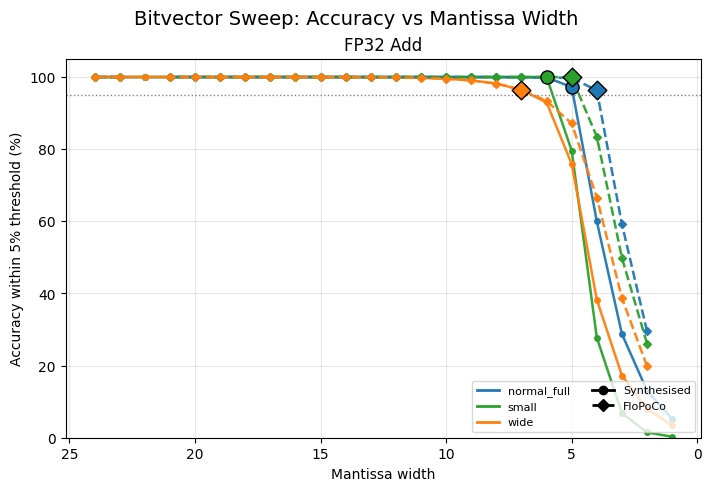

In [26]:
# ──────── Bitvector Sweep: Knee Analysis + Accuracy vs Width ────────
# Focuses on the smallest mantissa width that still satisfies a target
# thresholded accuracy, then uses those knee points for downstream plots.

import re
from pathlib import Path
from matplotlib.lines import Line2D

BV_MODE_ORDER = ["normal_full", "small", "wide"]
BV_TARGET_ORDER = ["fp32_add", "fp32_mul", "mxint8_add", "mxint8_mul"]
BV_TARGET_LABELS = {
    "fp32_add": "FP32 Add",
    "fp32_mul": "FP32 Mul",
    "mxint8_add": "MXINT8 Add",
    "mxint8_mul": "MXINT8 Mul",
}
BV_FAMILY_LABELS = {"synthesised": "Synthesised", "flopoco": "FloPoCo"}
BV_KNEE_THRESHOLDS = {"FP32": 95.0, "MXINT8": 75.0}
BV_KNEE_DROP_THRESHOLDS = {"FP32": 10.0, "MXINT8": 10.0}
BV_MODE_COLORS = {"normal_full": "#1f77b4", "small": "#2ca02c", "wide": "#ff7f0e"}
BV_FAMILY_STYLES = {"synthesised": "-", "flopoco": "--"}
BV_FAMILY_MARKERS = {"synthesised": "o", "flopoco": "D"}
BV_MAIN_TARGETS = ["fp32_mul", "mxint8_add", "mxint8_mul"]
BV_APPENDIX_TARGETS = ["fp32_add"]

if "bv_df" not in globals() or bv_df.empty:
    print("No bitvector sweep data loaded. Run the sweep-loader cell first.")
else:
    bv_analysis = bv_df.copy()

    def _pct_series(series):
        vals = pd.to_numeric(series, errors="coerce")
        return np.where(vals <= 1.0, vals * 100.0, vals)

    bv_analysis = bv_analysis.dropna(subset=["target", "mantissa_bits"]).copy()
    bv_analysis["mantissa_bits"] = pd.to_numeric(bv_analysis["mantissa_bits"], errors="coerce")
    bv_analysis = bv_analysis.dropna(subset=["mantissa_bits"]).copy()
    bv_analysis["mantissa_bits"] = bv_analysis["mantissa_bits"].astype(int)

    acc_source = "within_rel_pct" if "within_rel_pct" in bv_analysis.columns else "accuracy_exact_match"
    bv_analysis["within5pct_pct"] = _pct_series(bv_analysis[acc_source])
    bv_analysis["exact_pct"] = _pct_series(bv_analysis["accuracy_exact_match"]) if "accuracy_exact_match" in bv_analysis.columns else np.nan

    def _mode_plot(row):
        mode = str(row.get("cocotb_mode_config", row.get("cocotb_mode", "")) or "")
        if row.get("family") == "synthesised" and str(row.get("target", "")).startswith("fp32") and mode == "bits":
            return "normal_full"
        return mode

    bv_analysis["mode_plot"] = bv_analysis.apply(_mode_plot, axis=1)
    bv_analysis = bv_analysis[bv_analysis["mode_plot"].isin(BV_MODE_ORDER)].copy()
    bv_analysis = bv_analysis[
        ~(
            bv_analysis["target"].astype(str).str.startswith("mxint8")
            & (bv_analysis["mode_plot"] == "wide")
        )
    ].copy()
    bv_analysis["dtype"] = np.where(bv_analysis["target"].astype(str).str.startswith("fp32"), "FP32", "MXINT8")
    bv_analysis["target_label"] = bv_analysis["target"].map(BV_TARGET_LABELS).fillna(bv_analysis["target"])
    bv_analysis["family_label"] = bv_analysis["family"].map(BV_FAMILY_LABELS).fillna(bv_analysis["family"])

    dedup_cols = [c for c in ["family", "target", "mode_plot", "mantissa_bits"] if c in bv_analysis.columns]
    if dedup_cols:
        bv_analysis = bv_analysis.sort_values(dedup_cols).drop_duplicates(subset=dedup_cols, keep="last")

    knee_rows = []
    for (family, target, mode), g in bv_analysis.groupby(["family", "target", "mode_plot"]):
        g = g.sort_values("mantissa_bits")
        dtype = "FP32" if str(target).startswith("fp32") else "MXINT8"
        threshold = BV_KNEE_THRESHOLDS[dtype]
        drop_threshold = BV_KNEE_DROP_THRESHOLDS[dtype]
        meets = g[g["within5pct_pct"] >= threshold]
        if not meets.empty:
            chosen = meets.sort_values("mantissa_bits").iloc[0]
            selection_status = "meets_threshold"
        else:
            g_desc = g.sort_values("mantissa_bits", ascending=False).reset_index(drop=True).copy()
            g_desc["next_within5pct_pct"] = g_desc["within5pct_pct"].shift(-1)
            g_desc["drop_to_next"] = g_desc["within5pct_pct"] - g_desc["next_within5pct_pct"]
            steep = g_desc[g_desc["drop_to_next"] >= drop_threshold]
            if not steep.empty:
                chosen = steep.iloc[0]
                selection_status = "pre_steep_drop"
            else:
                chosen = g.sort_values(["within5pct_pct", "mantissa_bits"], ascending=[False, True]).iloc[0]
                selection_status = "best_available"
        knee_rows.append({
            "target": target,
            "target_label": BV_TARGET_LABELS.get(target, target),
            "dtype": dtype,
            "family": family,
            "family_label": BV_FAMILY_LABELS.get(family, family),
            "mode": mode,
            "threshold_pct": threshold,
            "mantissa_bits": int(chosen["mantissa_bits"]),
            "within5pct": float(chosen["within5pct_pct"]),
            "exact_pct": float(chosen["exact_pct"]) if pd.notna(chosen["exact_pct"]) else np.nan,
            "LUTs": float(chosen["LUTs"]) if pd.notna(chosen.get("LUTs")) else np.nan,
            "FFs": float(chosen["FFs"]) if pd.notna(chosen.get("FFs")) else np.nan,
            "Cycles": float(chosen["Cycles"]) if pd.notna(chosen.get("Cycles")) else np.nan,
            "Latency_ns": float(chosen["Latency_ns"]) if pd.notna(chosen.get("Latency_ns")) else np.nan,
            "ADP": float(chosen["adp_lut_ns"]) if pd.notna(chosen.get("adp_lut_ns")) else np.nan,
            "selection_status": selection_status,
            "run_dir": chosen.get("run_dir", ""),
        })

    bv_knee_df = pd.DataFrame(knee_rows)
    bv_knee_df["target"] = pd.Categorical(bv_knee_df["target"], categories=BV_TARGET_ORDER, ordered=True)
    bv_knee_df["mode"] = pd.Categorical(bv_knee_df["mode"], categories=BV_MODE_ORDER, ordered=True)
    bv_knee_df["family_label"] = pd.Categorical(bv_knee_df["family_label"], categories=["Synthesised", "FloPoCo"], ordered=True)
    bv_knee_df = bv_knee_df.sort_values(["target", "family_label", "mode"]).reset_index(drop=True)

    def _make_knee_table(df):
        tbl = df[[
            "target_label", "family_label", "mode", "threshold_pct", "mantissa_bits",
            "within5pct", "exact_pct", "LUTs", "FFs", "Cycles", "Latency_ns", "ADP", "selection_status"
        ]].rename(columns={
            "target_label": "Benchmark",
            "family_label": "Design",
            "mode": "Mode",
            "threshold_pct": "Threshold (%)",
            "mantissa_bits": "Knee Mantissa",
            "within5pct": "Within-5%",
            "exact_pct": "Exact match",
            "Latency_ns": "Latency (ns)",
            "selection_status": "Selection",
        })
        return tbl.round({
            "Threshold (%)": 1,
            "Within-5%": 2,
            "Exact match": 2,
            "LUTs": 1,
            "FFs": 1,
            "Cycles": 1,
            "Latency (ns)": 3,
            "ADP": 3,
        })

    def _print_knee_block(title, df):
        tbl = _make_knee_table(df)
        print(title)
        if "display" in globals():
            display(tbl)
        else:
            print(tbl)
        latex_df = tbl.copy()
        for col in ["Within-5%", "Exact match", "Threshold (%)"]:
            latex_df[col] = latex_df[col].map(lambda x: f"{x:.2f}\\%" if pd.notna(x) else "NaN")
        for col in ["LUTs", "FFs", "Cycles"]:
            latex_df[col] = latex_df[col].map(lambda x: f"{x:.1f}" if pd.notna(x) else "NaN")
        for col in ["Latency (ns)", "ADP"]:
            latex_df[col] = latex_df[col].map(lambda x: f"{x:.3f}" if pd.notna(x) else "NaN")
        print(f"LaTeX table for {title}:")
        print(latex_df.to_latex(index=False, escape=False))
        return tbl

    bv_knee_table_main = _print_knee_block(
        "Bitvector knee-point summary (Main text)",
        bv_knee_df[bv_knee_df["target"].astype(str).isin(BV_MAIN_TARGETS)].copy(),
    )
    bv_knee_table_appendix = _print_knee_block(
        "Bitvector knee-point summary (Appendix / FP32 Add)",
        bv_knee_df[bv_knee_df["target"].astype(str).isin(BV_APPENDIX_TARGETS)].copy(),
    )

    def _plot_accuracy_vs_width(targets, title):
        fig, axes = plt.subplots(1, len(targets), figsize=(7 * len(targets), 4.8), constrained_layout=True, sharey=True)
        if len(targets) == 1:
            axes = [axes]
        for ax, target in zip(axes, targets):
            panel = bv_analysis[bv_analysis["target"] == target].copy()
            if panel.empty:
                ax.set_visible(False)
                continue
            dtype = "FP32" if target.startswith("fp32") else "MXINT8"
            threshold = BV_KNEE_THRESHOLDS[dtype]
            for family in ["synthesised", "flopoco"]:
                fam = panel[panel["family"] == family]
                if fam.empty:
                    continue
                for mode in BV_MODE_ORDER:
                    line = fam[fam["mode_plot"] == mode].sort_values("mantissa_bits")
                    if line.empty:
                        continue
                    ax.plot(
                        line["mantissa_bits"],
                        line["within5pct_pct"],
                        color=BV_MODE_COLORS[mode],
                        linestyle=BV_FAMILY_STYLES[family],
                        marker=BV_FAMILY_MARKERS[family],
                        markersize=4,
                        linewidth=1.8,
                        alpha=0.95,
                    )
                    knee_match = bv_knee_df[
                        (bv_knee_df["target"].astype(str) == target)
                        & (bv_knee_df["family"] == family)
                        & (bv_knee_df["mode"].astype(str) == mode)
                    ]
                    if not knee_match.empty:
                        knee = knee_match.iloc[0]
                        ax.scatter(
                            [knee["mantissa_bits"]],
                            [knee["within5pct"]],
                            s=90,
                            color=BV_MODE_COLORS[mode],
                            marker=BV_FAMILY_MARKERS[family],
                            edgecolors="black",
                            linewidth=1.0,
                            zorder=5,
                        )
            ax.axhline(threshold, color="gray", linestyle=":", linewidth=1.0)
            ax.set_title(BV_TARGET_LABELS[target])
            ax.set_xlabel("Mantissa width")
            ax.set_ylabel("Accuracy within 5% threshold (%)")
            ax.grid(alpha=0.3)
            ax.set_ylim(0, 105)
            ax.invert_xaxis()
        handles = [Line2D([0], [0], color=BV_MODE_COLORS[m], linewidth=2, label=m) for m in BV_MODE_ORDER if any((bv_analysis["mode_plot"] == m))]
        handles += [
            Line2D([0], [0], color="black", linestyle=BV_FAMILY_STYLES[f], marker=BV_FAMILY_MARKERS[f], linewidth=2, label=BV_FAMILY_LABELS[f])
            for f in ["synthesised", "flopoco"]
        ]
        axes[0].legend(handles=handles, fontsize=8, ncol=2, loc="lower right")
        fig.suptitle(title, fontsize=14)
        plt.show()

    _plot_accuracy_vs_width(BV_MAIN_TARGETS, "Bitvector Sweep: Accuracy vs Mantissa Width")
    _plot_accuracy_vs_width(BV_APPENDIX_TARGETS, "Bitvector Sweep: Accuracy vs Mantissa Width")

    globals()["bv_analysis"] = bv_analysis
    globals()["bv_knee_df"] = bv_knee_df
    globals()["bv_knee_table_main"] = bv_knee_table_main
    globals()["bv_knee_table_appendix"] = bv_knee_table_appendix


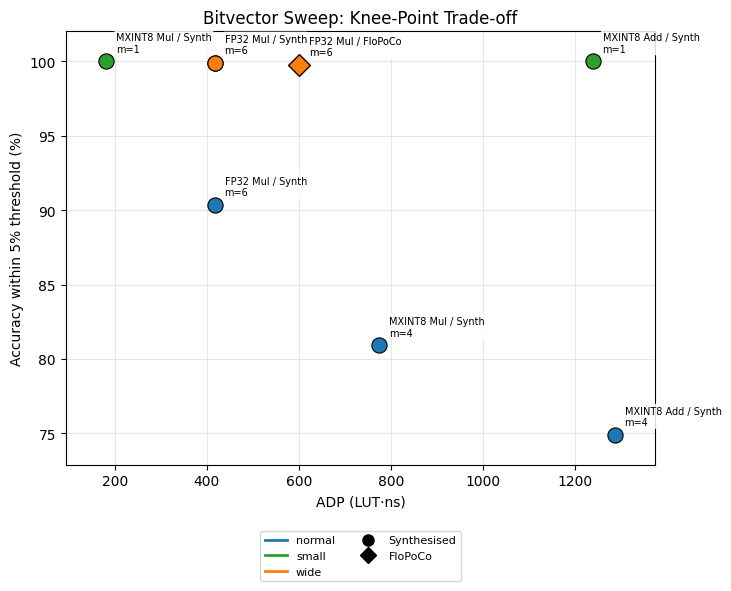

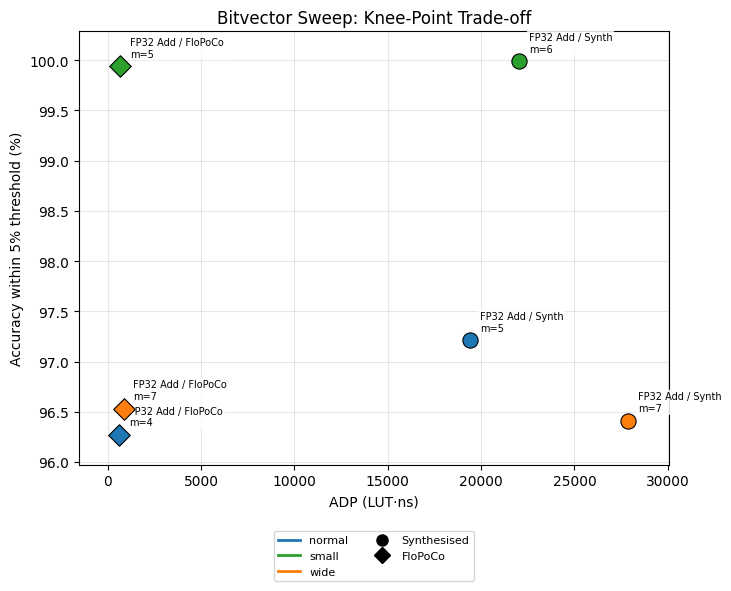

/home/josephluke/Program-Synthesis-for-Efficient-ML/.venv/lib64/python3.11/site-packages/numpy/_core/function_base.py:163: RuntimeWarning: invalid value encountered in multiply
  y *= step
/home/josephluke/Program-Synthesis-for-Efficient-ML/.venv/lib64/python3.11/site-packages/numpy/lib/_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/home/josephluke/Program-Synthesis-for-Efficient-ML/.venv/lib64/python3.11/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/home/josephluke/Program-Synthesis-for-Efficient-ML/.venv/lib64/python3.11/site-packages/matplotlib/mlab.py:904: RuntimeWarning: invalid value encountered in subtract
  diff = self.dataset - points[:, i, np.newaxis]


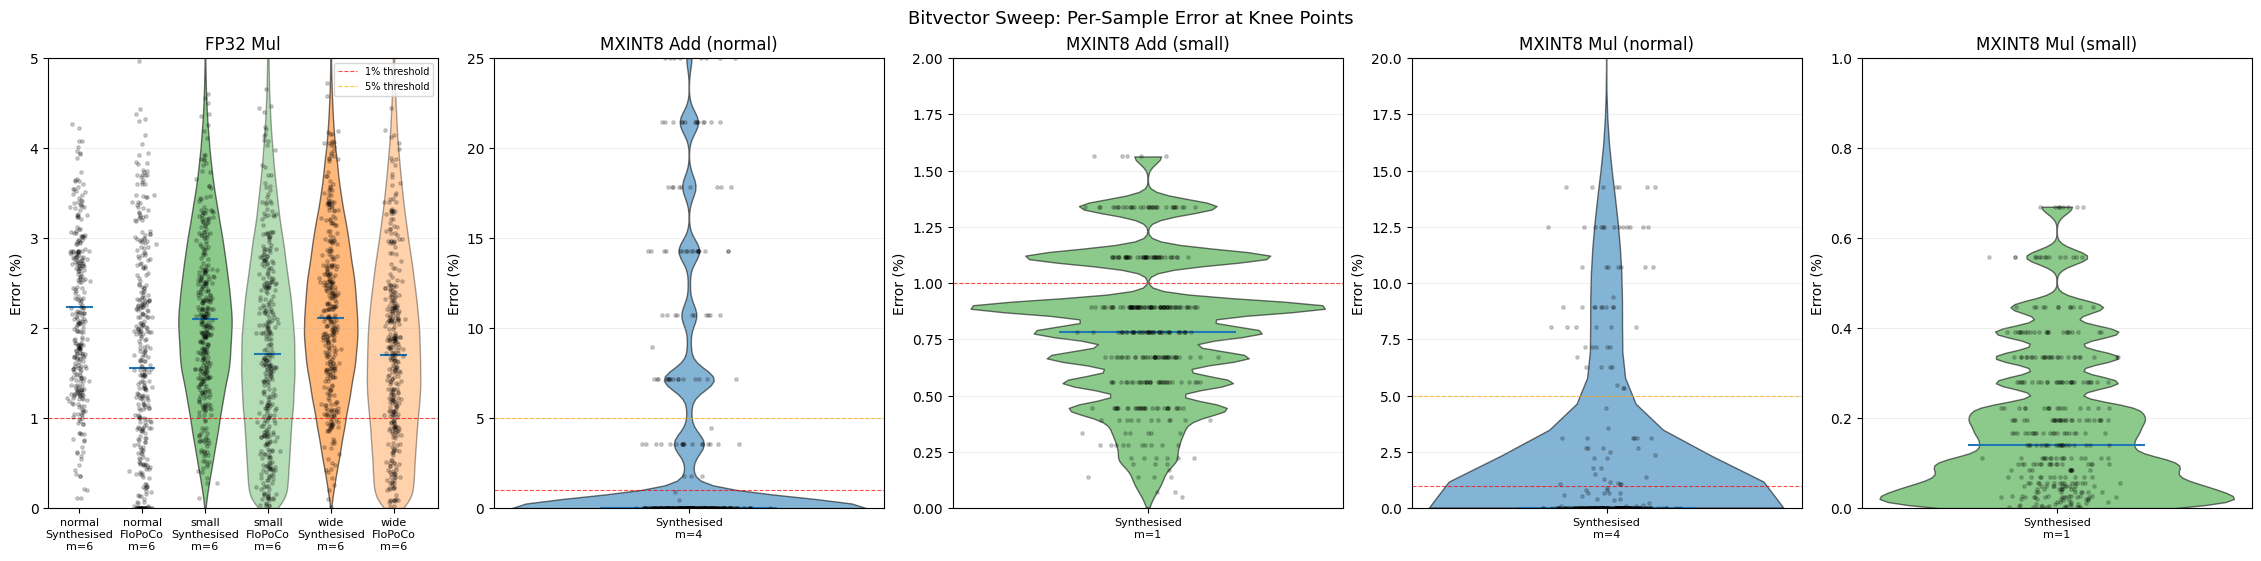

/home/josephluke/Program-Synthesis-for-Efficient-ML/.venv/lib64/python3.11/site-packages/numpy/_core/function_base.py:163: RuntimeWarning: invalid value encountered in multiply
  y *= step
/home/josephluke/Program-Synthesis-for-Efficient-ML/.venv/lib64/python3.11/site-packages/numpy/lib/_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/home/josephluke/Program-Synthesis-for-Efficient-ML/.venv/lib64/python3.11/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/home/josephluke/Program-Synthesis-for-Efficient-ML/.venv/lib64/python3.11/site-packages/matplotlib/mlab.py:904: RuntimeWarning: invalid value encountered in subtract
  diff = self.dataset - points[:, i, np.newaxis]


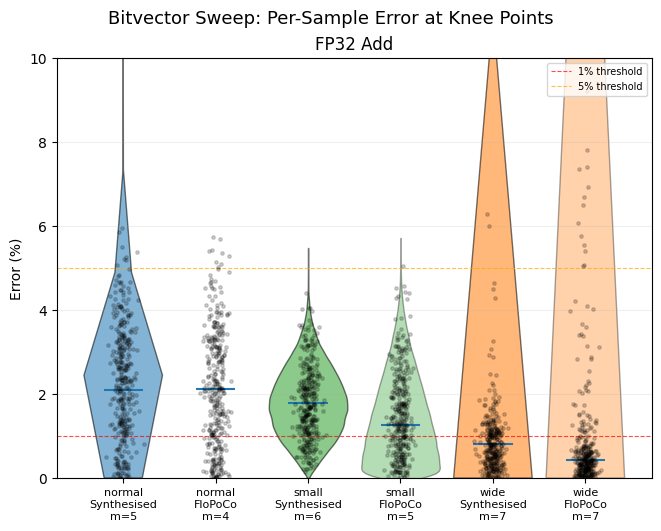

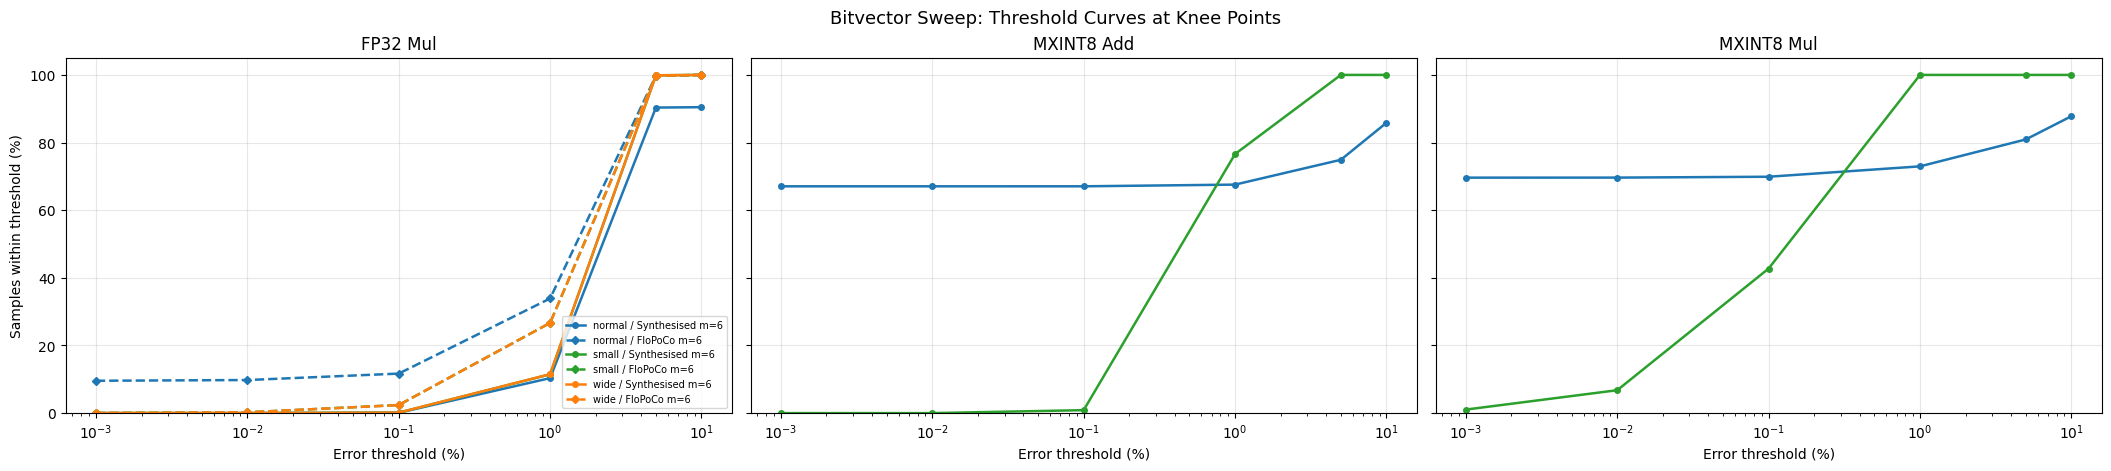

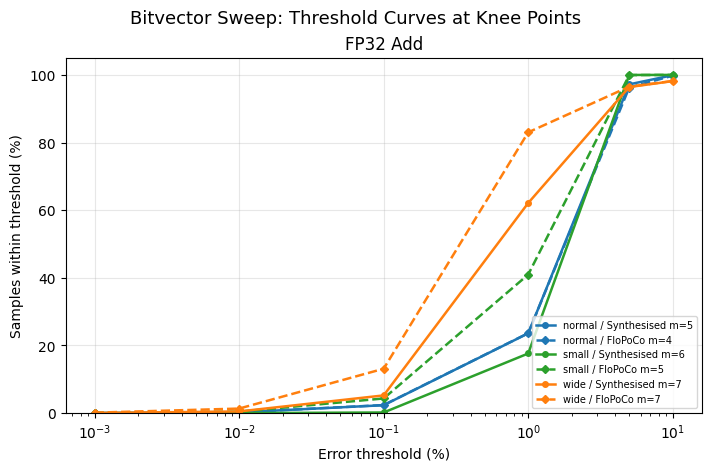

In [27]:
# ──────── Bitvector Sweep: Knee-Point Comparison + Violin Plots ────────

import re
from pathlib import Path
from matplotlib.lines import Line2D

if "bv_knee_df" not in globals() or bv_knee_df.empty:
    print("No knee-point bitvector summary found. Run the knee-analysis cell first.")
else:
    knee_plot = bv_knee_df.dropna(subset=["ADP", "within5pct"]).copy()
    if not knee_plot.empty:
        MODE_COLORS = {
            "normal_full": "#1f77b4",
            "small": "#2ca02c",
            "wide": "#ff7f0e",
        }
        FAMILY_MARKERS = {"Synthesised": "o", "FloPoCo": "D"}
        MODE_SHORT = {"normal_full": "normal", "small": "small", "wide": "wide"}
        TARGET_SHORT = {"fp32_add": "FP32 Add", "fp32_mul": "FP32 Mul", "mxint8_add": "MXINT8 Add", "mxint8_mul": "MXINT8 Mul"}

        def _plot_tradeoff(targets, title):
            fig, ax = plt.subplots(1, 1, figsize=(7.2, 5.8), constrained_layout=True)
            panel = knee_plot[knee_plot["target"].astype(str).isin(targets)].copy()
            if panel.empty:
                print(f"No knee-point trade-off data for {title}.")
                return
            for _, row in panel.iterrows():
                ax.scatter(
                    row["ADP"], row["within5pct"],
                    color=MODE_COLORS.get(str(row["mode"]), "gray"),
                    marker=FAMILY_MARKERS.get(str(row["family_label"]), "o"),
                    s=120,
                    edgecolors="black",
                    linewidth=0.8,
                    zorder=3,
                )
                family_short = "Synth" if str(row["family_label"]) == "Synthesised" else "FloPoCo"
                label = f"{TARGET_SHORT.get(str(row['target']), str(row['target']))} / {family_short}\nm={int(row['mantissa_bits'])}"
                ax.annotate(
                    label,
                    (row["ADP"], row["within5pct"]),
                    xytext=(7, 7),
                    textcoords="offset points",
                    fontsize=7,
                    ha="left",
                    bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.85),
                )
            ax.set_xlabel("ADP (LUT·ns)")
            ax.set_ylabel("Accuracy within 5% threshold (%)")
            ax.set_title(title)
            ax.grid(alpha=0.3)
            ax.margins(x=0.08, y=0.08)
            legend_handles = [
                Line2D([0], [0], color=c, linewidth=2, label=MODE_SHORT.get(m, m))
                for m, c in MODE_COLORS.items() if m in panel["mode"].astype(str).unique()
            ]
            legend_handles += [
                Line2D([0], [0], marker=m, color="black", linestyle="None", label=fam, markersize=8)
                for fam, m in FAMILY_MARKERS.items() if fam in panel["family_label"].astype(str).unique()
            ]
            ax.legend(handles=legend_handles, fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.14), frameon=True)
            plt.show()

        _plot_tradeoff(["fp32_mul", "mxint8_add", "mxint8_mul"], "Bitvector Sweep: Knee-Point Trade-off")
        _plot_tradeoff(["fp32_add"], "Bitvector Sweep: Knee-Point Trade-off")

    def _npz_mode_normalized(family, target, mode):
        if family == "synthesised" and str(target).startswith("fp32") and mode == "bits":
            return "normal_full"
        return mode

    def _parse_npz_meta(npz_path):
        stem = npz_path.stem
        target = None
        if "fp32addition" in stem:
            target = "fp32_add"
        elif "fp32multiplication" in stem:
            target = "fp32_mul"
        elif "mxint8addition" in stem:
            target = "mxint8_add"
        elif "mxint8multiplication" in stem:
            target = "mxint8_mul"
        m = re.search(r"_m(\d+)_([A-Za-z_]+)$", stem)
        if not target or not m:
            return None
        mantissa_bits = int(m.group(1))
        raw_mode = m.group(2)
        family = "flopoco" if "flopoco" in str(npz_path) else "synthesised"
        mode_plot = _npz_mode_normalized(family, target, raw_mode)
        return {
            "path": npz_path,
            "family": family,
            "target": target,
            "mantissa_bits": mantissa_bits,
            "raw_mode": raw_mode,
            "mode_plot": mode_plot,
        }

    def _load_npz_errors(npz_path):
        data = np.load(npz_path, allow_pickle=True)
        if "rel_err_pct" in data:
            return np.abs(data["rel_err_pct"])
        if "abs_err_quant" in data:
            full_scale = float(data["full_scale"][0]) if "full_scale" in data else 112.0
            return np.abs(data["abs_err_quant"]) / full_scale * 100.0
        return None

    npz_index = {}
    for npz_path in sorted(Path(PROD_SWEEPS_ROOT).rglob("error_samples/*.npz")):
        meta = _parse_npz_meta(npz_path)
        if not meta:
            continue
        npz_index[(meta["family"], meta["target"], meta["mode_plot"], meta["mantissa_bits"])] = meta["path"]

    knee_error_records = []
    for _, row in bv_knee_df.iterrows():
        key = (str(row["family"]), str(row["target"]), str(row["mode"]), int(row["mantissa_bits"]))
        npz_path = npz_index.get(key)
        if npz_path is None:
            continue
        errs = _load_npz_errors(npz_path)
        if errs is None or len(errs) == 0:
            continue
        knee_error_records.append({
            "target": str(row["target"]),
            "target_label": BV_TARGET_LABELS.get(str(row["target"]), str(row["target"])),
            "family_label": str(row["family_label"]),
            "mode": str(row["mode"]),
            "mantissa_bits": int(row["mantissa_bits"]),
            "errors": errs,
        })

    if knee_error_records:
        BV_VIOLIN_SPECS_MAIN = [
            ("fp32_mul", None, "FP32 Mul"),
            ("mxint8_add", "normal_full", "MXINT8 Add (normal)"),
            ("mxint8_add", "small", "MXINT8 Add (small)"),
            ("mxint8_mul", "normal_full", "MXINT8 Mul (normal)"),
            ("mxint8_mul", "small", "MXINT8 Mul (small)"),
        ]
        BV_VIOLIN_SPECS_APPENDIX = [
            ("fp32_add", None, "FP32 Add"),
        ]
        BV_VIOLIN_YLIMS = {
            ("fp32_add", None): (0.0, 10.0),
            ("fp32_mul", None): (0.0, 5.0),
            ("mxint8_add", "normal_full"): (0.0, 25.0),
            ("mxint8_add", "small"): (0.0, 2.0),
            ("mxint8_mul", "normal_full"): (0.0, 20.0),
            ("mxint8_mul", "small"): (0.0, 1.0),
        }

        def _plot_violin_group(specs, nrows, ncols, figsize, suptitle):
            fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True, squeeze=False)
            flat_axes = list(axes.ravel())
            for idx, (target, mode_filter, panel_title) in enumerate(specs):
                ax = flat_axes[idx]
                rows = [r for r in knee_error_records if r["target"] == target and (mode_filter is None or r["mode"] == mode_filter)]
                if not rows:
                    ax.set_visible(False)
                    continue
                rows.sort(key=lambda r: (BV_MODE_ORDER.index(r["mode"]), 0 if r["family_label"] == "Synthesised" else 1))
                positions = list(range(len(rows)))
                data_arrays = [r["errors"] for r in rows]
                labels = [
                    f"{MODE_SHORT.get(r['mode'], r['mode'])}\n{r['family_label']}\nm={r['mantissa_bits']}" if mode_filter is None else f"{r['family_label']}\nm={r['mantissa_bits']}"
                    for r in rows
                ]
                parts = ax.violinplot(data_arrays, positions=positions, showmedians=True, showextrema=False, widths=0.85)
                for body, r in zip(parts["bodies"], rows):
                    body.set_facecolor(BV_MODE_COLORS.get(r["mode"], "#999999"))
                    body.set_edgecolor("black")
                    body.set_alpha(0.55 if r["family_label"] == "Synthesised" else 0.35)
                for pos, arr, r in zip(positions, data_arrays, rows):
                    n_show = min(len(arr), 350)
                    if n_show == 0:
                        continue
                    sample_idx = np.random.choice(len(arr), n_show, replace=False)
                    x_jitter = np.random.normal(pos, 0.06, size=n_show)
                    ax.scatter(x_jitter, arr[sample_idx], s=6, alpha=0.18, color="black", zorder=3)
                ax.axhline(1.0, color="red", linestyle="--", linewidth=0.8, alpha=0.7, label="1% threshold")
                ax.axhline(5.0, color="orange", linestyle="--", linewidth=0.8, alpha=0.7, label="5% threshold")
                ax.set_xticks(positions)
                ax.set_xticklabels(labels, fontsize=8)
                ax.set_ylabel("Error (%)")
                ax.set_title(panel_title)
                ax.grid(axis="y", alpha=0.2)
                ylim = BV_VIOLIN_YLIMS.get((target, mode_filter))
                if ylim is not None:
                    ax.set_ylim(*ylim)
                if idx == 0:
                    ax.legend(fontsize=7, loc="upper right")
            for ax in flat_axes[len(specs):]:
                ax.set_visible(False)
            fig.suptitle(suptitle, fontsize=13)
            plt.show()

        _plot_violin_group(
            BV_VIOLIN_SPECS_MAIN,
            nrows=1,
            ncols=5,
            figsize=(22.5, 5.5),
            suptitle="Bitvector Sweep: Per-Sample Error at Knee Points",
        )
        _plot_violin_group(
            BV_VIOLIN_SPECS_APPENDIX,
            nrows=1,
            ncols=1,
            figsize=(6.5, 5.2),
            suptitle="Bitvector Sweep: Per-Sample Error at Knee Points",
        )
    else:
        print("No per-sample NPZ matches found for the selected knee points.")

    if knee_error_records:
        THRESHOLDS = [0.001, 0.01, 0.1, 1.0, 5.0, 10.0]

        def _plot_threshold_curves(targets, title):
            fig, axes = plt.subplots(1, len(targets), figsize=(7 * len(targets), 4.6), constrained_layout=True, squeeze=False, sharey=True)
            for idx, target in enumerate(targets):
                ax = axes[0][idx]
                rows = [r for r in knee_error_records if r["target"] == target]
                if not rows:
                    ax.set_visible(False)
                    continue
                rows.sort(key=lambda r: (BV_MODE_ORDER.index(r["mode"]), 0 if r["family_label"] == "Synthesised" else 1))
                for r in rows:
                    pcts = [100.0 * np.mean(np.abs(r["errors"]) <= t) for t in THRESHOLDS]
                    ax.plot(
                        THRESHOLDS, pcts,
                        color=BV_MODE_COLORS.get(r["mode"], "#999999"),
                        linestyle='-' if r["family_label"] == "Synthesised" else '--',
                        marker='o' if r["family_label"] == "Synthesised" else 'D',
                        markersize=4, linewidth=1.8,
                        label=f"{MODE_SHORT.get(r['mode'], r['mode'])} / {r['family_label']} m={r['mantissa_bits']}"
                    )
                ax.set_xscale("log")
                ax.set_xlabel("Error threshold (%)")
                ax.set_title(BV_TARGET_LABELS[target])
                ax.grid(alpha=0.3)
                ax.set_ylim(0, 105)
                if idx == 0:
                    ax.set_ylabel("Samples within threshold (%)")
                    ax.legend(fontsize=7, loc="lower right")
            fig.suptitle(title, fontsize=13)
            plt.show()

        _plot_threshold_curves(["fp32_mul", "mxint8_add", "mxint8_mul"], "Bitvector Sweep: Threshold Curves at Knee Points")
        _plot_threshold_curves(["fp32_add"], "Bitvector Sweep: Threshold Curves at Knee Points")


## 4d. Grammar Complexity vs Synthesis Time

Do grammars with larger (bounded) search spaces take longer to solve?  
Each synthesis target has a documented search-space size in its `.sl` template file.  
This cell correlates that count with the observed synthesis wall-clock time from Section 1,  
providing a principled justification for the structural-sketch grammar design decisions.

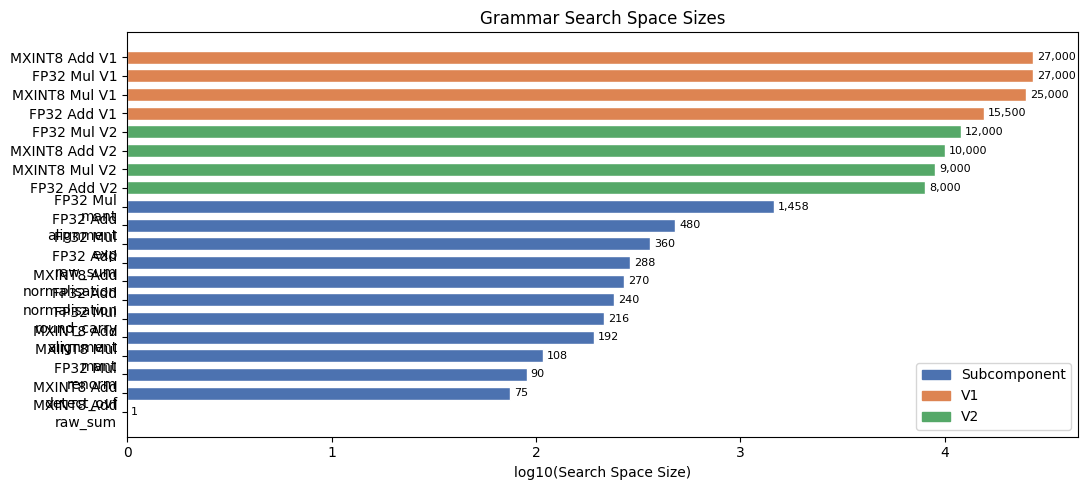

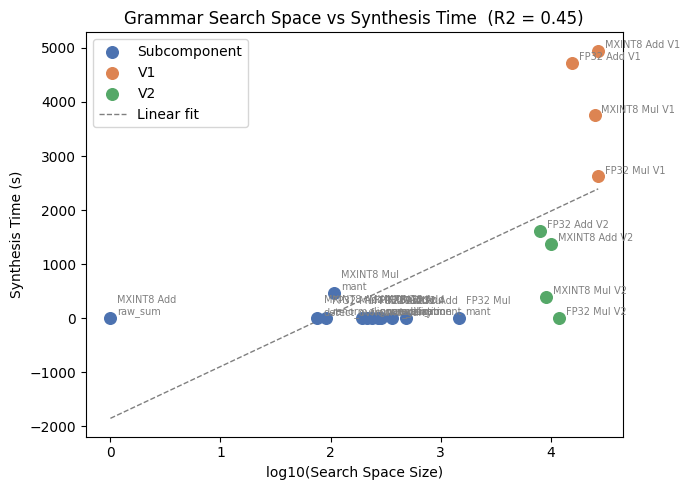

,Grammar,Search Space,Synth Time (s),Type
0,MXINT8 Add\nalignment,192,8.6,Subcomponent
1,MXINT8 Add\nnormalisation,270,8.6,Subcomponent
2,MXINT8 Add\ndetect_ovf,75,8.6,Subcomponent
3,MXINT8 Add\nraw_sum,1,8.6,Subcomponent
4,FP32 Add\nalignment,480,2.3,Subcomponent
5,FP32 Add\nraw_sum,288,2.3,Subcomponent
6,FP32 Add\nnormalisation,240,2.3,Subcomponent
7,MXINT8 Mul\nmant,108,469.7,Subcomponent
8,MXINT8 Mul\nexp,Recursive,469.7,Recursive
9,MXINT8 Mul\nrenorm_flag,Recursive,469.7,Recursive


In [28]:
# ──────── 4d. Grammar Complexity vs Synthesis Time ────────
# Uses grammar_selection study data if available (has per-run timing + grammar metrics),
# otherwise falls back to hardcoded search-space metadata.

GRAMMAR_META = [
    # (label, search_space, variant, benchmark, is_recursive)
    ("MXINT8 Add\nalignment",     192,   "Subcomponents", "mxint8_add", False),
    ("MXINT8 Add\nnormalisation", 270,   "Subcomponents", "mxint8_add", False),
    ("MXINT8 Add\ndetect_ovf",     75,   "Subcomponents", "mxint8_add", False),
    ("MXINT8 Add\nraw_sum",         1,   "Subcomponents", "mxint8_add", False),
    ("FP32 Add\nalignment",       480,   "Subcomponents", "fp32_add",   False),
    ("FP32 Add\nraw_sum",         288,   "Subcomponents", "fp32_add",   False),
    ("FP32 Add\nnormalisation",   240,   "Subcomponents", "fp32_add",   False),
    ("MXINT8 Mul\nmant",          108,   "Subcomponents", "mxint8_mul", False),
    ("MXINT8 Mul\nexp",          None,   "Subcomponents", "mxint8_mul", True),
    ("MXINT8 Mul\nrenorm_flag",  None,   "Subcomponents", "mxint8_mul", True),
    ("FP32 Mul\nexp",             360,   "Subcomponents", "fp32_mul",   False),
    ("FP32 Mul\nmant",           1458,   "Subcomponents", "fp32_mul",   False),
    ("FP32 Mul\nrenorm",           90,   "Subcomponents", "fp32_mul",   False),
    ("FP32 Mul\nround_carry",     216,   "Subcomponents", "fp32_mul",   False),
    ("MXINT8 Add V1",          27000,   "V1",            "mxint8_add", False),
    ("FP32 Add V1",            15500,   "V1",            "fp32_add",   False),
    ("MXINT8 Mul V1",         25000,   "V1",            "mxint8_mul", False),
    ("FP32 Mul V1",            27000,   "V1",            "fp32_mul",   False),
    ("MXINT8 Add V2",          10000,   "V2",            "mxint8_add", False),
    ("FP32 Add V2",             8000,   "V2",            "fp32_add",   False),
    ("MXINT8 Mul V2",          9000,   "V2",            "mxint8_mul", False),
    ("FP32 Mul V2",            12000,   "V2",            "fp32_mul",   False),
]

# ── Try to get synthesis times from grammar_selection study or pipeline logs ──
has_gs = "gs_df" in dir() and not gs_df.empty

gc_rows = []
for label, search_space, variant, benchmark, is_recursive in GRAMMAR_META:
    synth_time = None

    # Prefer grammar_selection study data
    if has_gs:
        sub = gs_df[(gs_df["benchmark"] == benchmark) & (gs_df["grammar_version"] == variant)]
        if not sub.empty and "solver_runtime_seconds_total" in sub.columns:
            synth_time = sub["solver_runtime_seconds_total"].mean()
            if pd.isna(synth_time) or synth_time < 0:
                synth_time = None

    gc_rows.append({
        "label": label,
        "search_space": search_space,
        "synth_time_s": synth_time,
        "recursive": is_recursive,
        "category": "V1" if "V1" in label else ("V2" if "V2" in label else ("Recursive" if is_recursive else "Subcomponent")),
    })

gc_df = pd.DataFrame(gc_rows)
has_times = gc_df["synth_time_s"].notna().any()

if not has_times:
    print("No synthesis timing data found. Run grammar selection study first.")
    print("Showing search-space bar chart only.\n")

# ── Plot 1: Search-space size bar chart ──
sketch_df = gc_df[~gc_df["recursive"]].copy().sort_values("search_space")
fig, ax = plt.subplots(figsize=(11, 5))
cat_colors = {"Subcomponent": "#4C72B0", "V1": "#DD8452", "V2": "#55A868"}
colors = sketch_df["category"].map(cat_colors).fillna("gray")
bars = ax.barh(sketch_df["label"],
               sketch_df["search_space"].apply(lambda x: np.log10(x) if x and x > 0 else 0),
               color=colors, edgecolor="white", height=0.7)
ax.set_xlabel("log10(Search Space Size)")
ax.set_title("Grammar Search Space Sizes")
for bar, (_, row) in zip(bars, sketch_df.iterrows()):
    if row["search_space"] and row["search_space"] > 0:
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                f"{int(row['search_space']):,}", va="center", fontsize=8)
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=l) for l, c in cat_colors.items()]
ax.legend(handles=legend_handles, loc="lower right")
plt.tight_layout()
plt.show()

# ── Plot 2: Search space vs synthesis time scatter ──
if has_times:
    plot_df = gc_df[~gc_df["recursive"] & gc_df["synth_time_s"].notna()].copy()
    fig, ax = plt.subplots(figsize=(7, 5))
    for cat, grp in plot_df.groupby("category"):
        color = cat_colors.get(cat, "gray")
        ax.scatter(np.log10(grp["search_space"].astype(float)), grp["synth_time_s"],
                   label=cat, color=color, s=70, zorder=3)
        for _, row in grp.iterrows():
            ax.annotate(row["label"], (np.log10(row["search_space"]), row["synth_time_s"]),
                        textcoords="offset points", xytext=(5, 2), fontsize=7, color="grey")
    xs = np.log10(plot_df["search_space"].astype(float))
    ys = plot_df["synth_time_s"].astype(float)
    if len(xs) >= 3:
        coeffs = np.polyfit(xs, ys, 1)
        xfit = np.linspace(xs.min(), xs.max(), 100)
        ax.plot(xfit, np.polyval(coeffs, xfit), "k--", linewidth=1, alpha=0.5, label="Linear fit")
        r2 = np.corrcoef(xs, ys)[0, 1] ** 2
        ax.set_title(f"Grammar Search Space vs Synthesis Time  (R2 = {r2:.2f})")
    else:
        ax.set_title("Grammar Search Space vs Synthesis Time")
    ax.set_xlabel("log10(Search Space Size)")
    ax.set_ylabel("Synthesis Time (s)")
    ax.legend()
    plt.tight_layout()
    plt.show()

# ── Summary table ──
tbl = gc_df[["label", "search_space", "synth_time_s", "category"]].copy()
tbl.columns = ["Grammar", "Search Space", "Synth Time (s)", "Type"]
tbl["Search Space"] = tbl["Search Space"].apply(lambda x: f"{int(x):,}" if pd.notna(x) else "Recursive")
tbl["Synth Time (s)"] = tbl["Synth Time (s)"].apply(lambda x: f"{x:.1f}" if pd.notna(x) else "\u2014")
display(tbl.reset_index(drop=True))

# 5. Cross-cutting Summary

Headline charts combining all experimental data.

Cross-cutting summary points used in the benchmark-wise trade-off plot:


,benchmark,source,label,ADP,accuracy
0,FP32 Add,Bitwidth Sweep,BV FloPoCo normal m=4,631.488000,96.270000
1,FP32 Add,Bitwidth Sweep,BV FloPoCo small m=5,658.944000,99.940000
2,FP32 Add,Bitwidth Sweep,BV FloPoCo wide m=7,855.712000,96.530000
3,FP32 Add,HP Sweep,HP V1,1407.687667,7.706667
4,FP32 Add,HP Sweep,HP V2,1621.452000,50.450000
5,FP32 Add,HP Sweep,HP Subcomp.,1914.898000,100.000000
6,FP32 Add,HP Sweep,HP FloPoCo,2081.190000,100.000000
7,FP32 Add,Relaxation Sweep,Relax V2 staged 32b,1671.600000,81.803333
8,FP32 Mul,Bitwidth Sweep,BV Synth normal m=6,417.456000,90.340000
9,FP32 Mul,Bitwidth Sweep,BV Synth small m=6,417.456000,99.890000


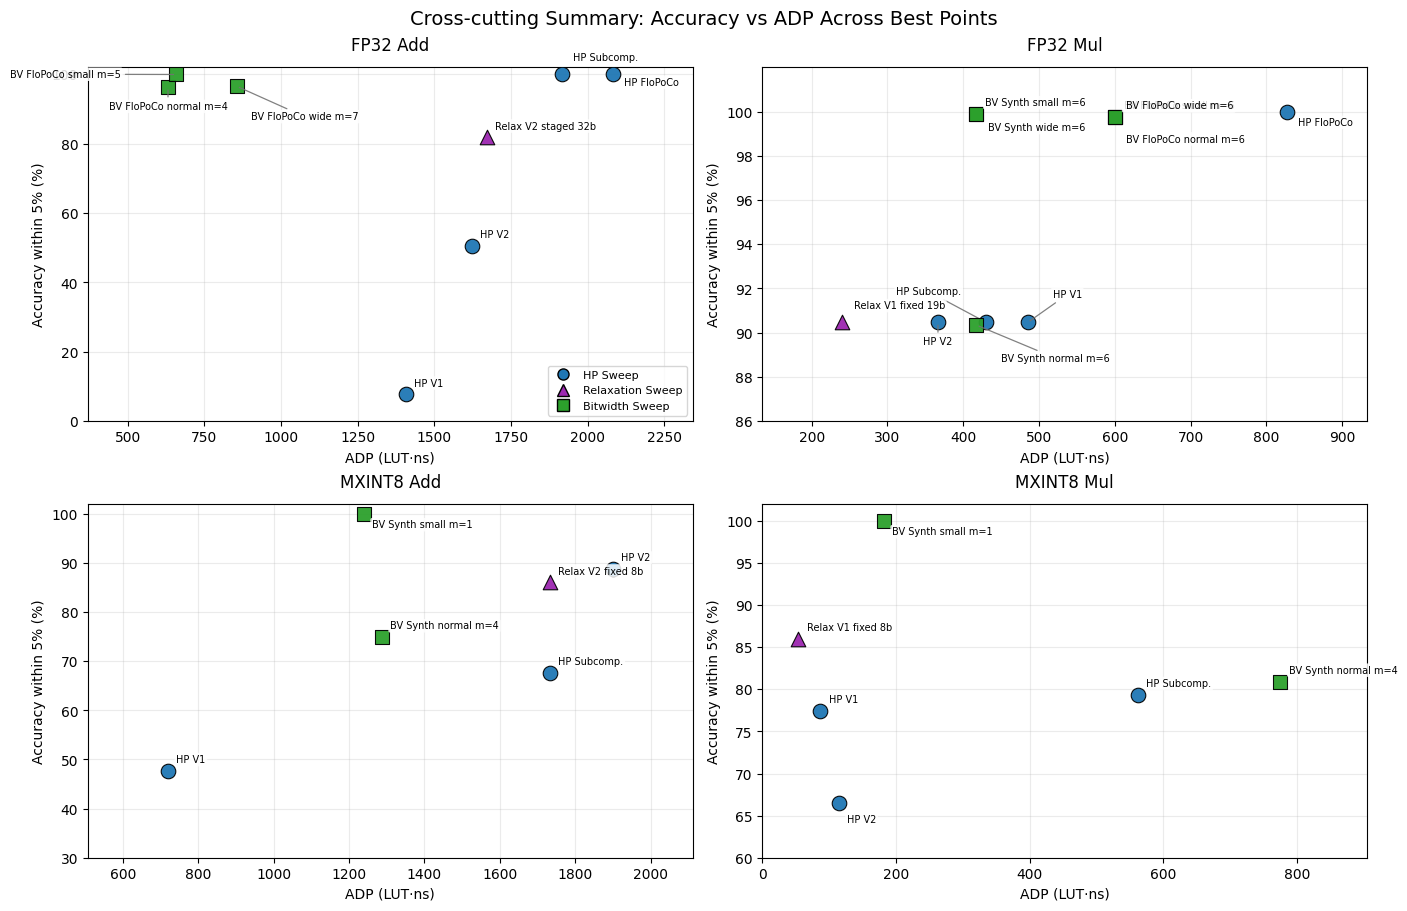

In [42]:
# ──────── Cross-Cutting Summary: Best Points Across Experiments ────────
# Combines the curated best points from:
# - Hyperparameter sweep / baseline selection
# - Relaxation sweep reporting points
# - Bitvector sweep knee points
# into one benchmark-wise accuracy-vs-ADP view.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

SUMMARY_BENCH_ORDER = [
    ("FP32", "Addition", "FP32 Add"),
    ("FP32", "Multiplication", "FP32 Mul"),
    ("MXINT8", "Addition", "MXINT8 Add"),
    ("MXINT8", "Multiplication", "MXINT8 Mul"),
]
SUMMARY_TARGET_TO_BENCH = {
    "fp32_add": "FP32 Add",
    "fp32_mul": "FP32 Mul",
    "mxint8_add": "MXINT8 Add",
    "mxint8_mul": "MXINT8 Mul",
}
SOURCE_STYLES = {
    "HP Sweep": ("o", "#1f77b4"),
    "Relaxation Sweep": ("^", "#9c27b0"),
    "Bitwidth Sweep": ("s", "#2ca02c"),
}
MODE_SHORT = {"normal_full": "normal", "small": "small", "wide": "wide", "bits": "bits"}
VARIANT_SHORT = {"Subcomponents": "Subcomp.", "FloPoCo": "FloPoCo", "V1": "V1", "V2": "V2"}
FAMILY_SHORT = {"Synthesised": "Synth", "FloPoCo": "FloPoCo"}
LABEL_SKIP = {
    ("FP32 Add", "Bitwidth Sweep", "BV Synth normal m=5"),
}
LABEL_OFFSETS = {
    ("FP32 Add", "HP Sweep", "HP Subcomp."): (8, 10, "left"),
    ("FP32 Add", "HP Sweep", "HP FloPoCo"): (8, -8, "left"),
    ("FP32 Add", "Bitwidth Sweep", "BV FloPoCo normal m=4"): (0, -16, "center"),
    ("FP32 Add", "Bitwidth Sweep", "BV FloPoCo small m=5"): (-40, -2, "right"),
    ("FP32 Add", "Bitwidth Sweep", "BV FloPoCo wide m=7"): (10, -24, "left"),
    ("FP32 Add", "Bitwidth Sweep", "BV Synth small m=6"): (8, -12, "left"),
    ("FP32 Add", "Bitwidth Sweep", "BV Synth wide m=7"): (8, -4, "left"),
    ("FP32 Mul", "HP Sweep", "HP Subcomp."): (-18, 20, "right"),
    ("FP32 Mul", "Relaxation Sweep", "Relax V1 fixed 19b"): (8, 10, "left"),
    ("FP32 Mul", "HP Sweep", "HP V1"): (18, 18, "left"),
    ("FP32 Mul", "HP Sweep", "HP V2"): (0, -16, "center"),
    ("FP32 Mul", "Bitwidth Sweep", "BV Synth normal m=6"): (18, -26, "left"),
    ("FP32 Mul", "HP Sweep", "HP FloPoCo"): (8, -10, "left"),
    ("FP32 Mul", "Bitwidth Sweep", "BV Synth wide m=6"): (8, -12, "left"),
    ("FP32 Mul", "Bitwidth Sweep", "BV FloPoCo normal m=6"): (8, -18, "left"),
    ("FP32 Mul", "Bitwidth Sweep", "BV FloPoCo wide m=6"): (8, 6, "left"),
    ("MXINT8 Add", "Bitwidth Sweep", "BV Synth small m=1"): (6, -10, "left"),
    ("MXINT8 Mul", "Bitwidth Sweep", "BV Synth small m=1"): (6, -10, "left"),
    ("MXINT8 Mul", "HP Sweep", "HP V2"): (6, -14, "left"),
}
LEADER_LINE_KEYS = {
    ("FP32 Add", "Bitwidth Sweep", "BV FloPoCo normal m=4"),
    ("FP32 Add", "Bitwidth Sweep", "BV FloPoCo small m=5"),
    ("FP32 Add", "Bitwidth Sweep", "BV FloPoCo wide m=7"),
    ("FP32 Mul", "HP Sweep", "HP Subcomp."),
    ("FP32 Mul", "HP Sweep", "HP V1"),
    ("FP32 Mul", "HP Sweep", "HP V2"),
    ("FP32 Mul", "Bitwidth Sweep", "BV Synth normal m=6"),
}

summary_rows = []

SUMMARY_OP_TO_SHORT = {"Addition": "Add", "Multiplication": "Mul"}

# ── HP sweep / recommended baseline points ──
if "hp_recommended" in globals() and isinstance(hp_recommended, pd.DataFrame) and not hp_recommended.empty:
    for _, row in hp_recommended.iterrows():
        op_short = SUMMARY_OP_TO_SHORT.get(str(row.get("op", "")), str(row.get("op", "")))
        bench = f"{row.get('dtype', '')} {op_short}".strip()
        if bench not in {b for _, _, b in SUMMARY_BENCH_ORDER}:
            continue
        acc = row.get("mean_within_rel_pct", np.nan)
        if pd.notna(acc) and acc <= 1.0:
            acc = float(acc) * 100.0
        summary_rows.append({
            "benchmark": bench,
            "ADP": float(row.get("mean_adp", np.nan)) if pd.notna(row.get("mean_adp", np.nan)) else np.nan,
            "accuracy": float(acc) if pd.notna(acc) else np.nan,
            "source": "HP Sweep",
            "label": f"HP {VARIANT_SHORT.get(str(row.get('variant')), str(row.get('variant')))}",
            "detail": str(row.get("variant", "")),
        })

# Add FloPoCo as the conventional HP/baseline reference when available.
if "hp_best_baseline_df" in globals() and isinstance(hp_best_baseline_df, pd.DataFrame) and not hp_best_baseline_df.empty:
    for _, row in hp_best_baseline_df[hp_best_baseline_df["variant"] == "FloPoCo"].iterrows():
        op_short = SUMMARY_OP_TO_SHORT.get(str(row.get("op", "")), str(row.get("op", "")))
        bench = f"{row.get('dtype', '')} {op_short}".strip()
        if bench not in {b for _, _, b in SUMMARY_BENCH_ORDER}:
            continue
        summary_rows.append({
            "benchmark": bench,
            "ADP": float(row.get("ADP", np.nan)) if pd.notna(row.get("ADP", np.nan)) else np.nan,
            "accuracy": float(row.get("within5pct", np.nan)) if pd.notna(row.get("within5pct", np.nan)) else np.nan,
            "source": "HP Sweep",
            "label": "HP FloPoCo",
            "detail": "FloPoCo",
        })

# ── Relaxation sweep reporting points ──
if "relax_report_df" in globals() and isinstance(relax_report_df, pd.DataFrame) and not relax_report_df.empty:
    for _, row in relax_report_df.iterrows():
        bench = SUMMARY_TARGET_TO_BENCH.get(str(row.get("benchmark")))
        if bench is None:
            continue
        summary_rows.append({
            "benchmark": bench,
            "ADP": float(row.get("adp_lut_ns", np.nan)) if pd.notna(row.get("adp_lut_ns", np.nan)) else np.nan,
            "accuracy": float(row.get("within_pct", np.nan)) if pd.notna(row.get("within_pct", np.nan)) else np.nan,
            "source": "Relaxation Sweep",
            "label": f"Relax {row.get('variant', '')} {row.get('relax_mode', '')} {int(row.get('match_bits'))}b",
            "detail": f"{row.get('variant', '')} {row.get('relax_mode', '')}",
        })

# ── BV sweep knee points ──
if "bv_knee_df" in globals() and isinstance(bv_knee_df, pd.DataFrame) and not bv_knee_df.empty:
    for _, row in bv_knee_df.iterrows():
        bench = SUMMARY_TARGET_TO_BENCH.get(str(row.get("target")))
        if bench is None:
            continue
        # FP32 Add synthesised BV points are intentionally omitted from this
        # cross-cutting summary because the helper rewrites are too structural
        # to interpret as a clean width-only truncation in the main text.
        if str(row.get("target")) == "fp32_add" and str(row.get("family_label")) == "Synthesised":
            continue
        summary_rows.append({
            "benchmark": bench,
            "ADP": float(row.get("ADP", np.nan)) if pd.notna(row.get("ADP", np.nan)) else np.nan,
            "accuracy": float(row.get("within5pct", np.nan)) if pd.notna(row.get("within5pct", np.nan)) else np.nan,
            "source": "Bitwidth Sweep",
            "label": f"BV {FAMILY_SHORT.get(str(row.get('family_label')), str(row.get('family_label')))} {MODE_SHORT.get(str(row.get('mode')), str(row.get('mode')))} m={int(row.get('mantissa_bits'))}",
            "detail": f"{row.get('family_label', '')} {row.get('mode', '')}",
        })

if not summary_rows:
    print("No data available for cross-cutting summary. Run previous sections first.")
else:
    cross_summary_df = pd.DataFrame(summary_rows)
    cross_summary_df = cross_summary_df.dropna(subset=["ADP", "accuracy"]).copy()
    cross_summary_df = cross_summary_df.sort_values(["benchmark", "source", "ADP", "accuracy"]).reset_index(drop=True)
    globals()["cross_summary_df"] = cross_summary_df

    print("Cross-cutting summary points used in the benchmark-wise trade-off plot:")
    display(cross_summary_df[["benchmark", "source", "label", "ADP", "accuracy"]])

    fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    axes = axes.flatten()

    for ax, (_, _, bench_label) in zip(axes, SUMMARY_BENCH_ORDER):
        sub = cross_summary_df[cross_summary_df["benchmark"] == bench_label].copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        x_min = sub["ADP"].min()
        x_max = sub["ADP"].max()
        x_span = max(x_max - x_min, max(x_max, 1.0) * 0.08)
        x_pad = max(50.0, x_span * 0.18)
        y_min = sub["accuracy"].min()
        y_max = sub["accuracy"].max()
        y_pad = max(3.0, (y_max - y_min) * 0.18 if y_max > y_min else 5.0)

        for source_name, (marker, color) in SOURCE_STYLES.items():
            sdf = sub[sub["source"] == source_name]
            if sdf.empty:
                continue
            ax.scatter(
                sdf["ADP"],
                sdf["accuracy"],
                s=110,
                marker=marker,
                color=color,
                edgecolors="black",
                linewidth=0.8,
                alpha=0.95,
                zorder=3,
            )
            for _, row in sdf.iterrows():
                key = (bench_label, source_name, row["label"])
                if key in LABEL_SKIP:
                    continue
                dx, dy, ha = LABEL_OFFSETS.get(key, (6, 6, "left"))
                ax.annotate(
                    row["label"],
                    (row["ADP"], row["accuracy"]),
                    xytext=(dx, dy),
                    textcoords="offset points",
                    fontsize=7,
                    ha=ha,
                    bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.85),
                    arrowprops=(dict(arrowstyle="-", color="0.45", lw=0.9, alpha=0.9, shrinkA=2, shrinkB=2) if key in LEADER_LINE_KEYS else None),
                )

        ax.set_title(bench_label, pad=12)
        ax.set_xlabel("ADP (LUT·ns)")
        ax.set_ylabel("Accuracy within 5% (%)")
        ax.set_xlim(max(0, x_min - x_pad), x_max + x_pad)
        ax.grid(alpha=0.25)
        top_ylim = 102 if y_max >= 99 else min(100, y_max + y_pad)
        ax.set_ylim(max(0, y_min - y_pad), top_ylim)
        ax.set_yticks([t for t in ax.get_yticks() if t <= 100])

    legend_handles = [
        Line2D([0], [0], marker=marker, color="w", markerfacecolor=color, markeredgecolor="black", markersize=8, label=src)
        for src, (marker, color) in SOURCE_STYLES.items()
    ]
    axes[0].legend(handles=legend_handles, fontsize=8, loc="lower right", frameon=True)
    plt.suptitle("Cross-cutting Summary: Accuracy vs ADP Across Best Points", fontsize=14)
    plt.show()